In [1]:
%%time
# =========================
# 0) Setup e imports - Competencia Data Mining UBA 2025
# =========================
!pip -q install polars==1.7.1 sympy matplotlib seaborn google-cloud-storage

import polars as pl
from pathlib import Path
from types import SimpleNamespace
import json, numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import optuna
from sympy import primerange
from google.cloud import storage

# Seeds oficiales de la competencia
SEEDS = [509963, 739373, 794341, 900623, 917827,
        946331, 682049, 415963, 163847, 846247,
        288203, 227407, 164513, 402299, 257437,
        789631, 812963, 361033, 698983, 827063,
        803591, 938053, 212791, 263759, 740023,
        426997, 507139, 185833, 929749, 412967,
        159473, 282571, 423853, 716707, 267133,
        895901, 115153, 173137, 228251, 568433,
        628937, 131591, 813961, 216421, 361327,
        759673, 105871, 484853, 239783, 724949,
]

# Paths definitivos en Google Cloud / repo git
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
SCHEMA_PATH = NOTEBOOK_DIR / "schema.json"
BASE_DIR    = NOTEBOOK_DIR / "dmeyf2025"

BUCKET_NAME = "nicocaviglia031_bukito3"
BUCKET_LOCAL_DIR = PROJECT_ROOT / BUCKET_NAME
BUCKET_LOCAL_DIR.mkdir(parents=True, exist_ok=True)


CPU times: user 4.78 s, sys: 365 ms, total: 5.15 s
Wall time: 4.62 s


In [2]:
# CSV_PATH    = PROJECT_ROOT / "datasets" / "competencia_02_crudo.csv"
# CSV_PATH2    = PROJECT_ROOT / "datasets" / "competencia_03_crudo.csv"
FINAL_PATH = PROJECT_ROOT / "datasets" / "competencia_03.csv"

# df1 = pd.read_csv(CSV_PATH)
# df2 = pd.read_csv(CSV_PATH2)
# df = pd.concat([df1, df2], ignore_index = True)
# df.to_csv(FINAL_PATH)


In [3]:
%%time
# =========================
# 1) Lectura de DF con Schema
# =========================

# Cargar schema
with open(SCHEMA_PATH) as f:
    schema_dict = json.load(f)

# Convertir strings a dtypes de Polars
schema = {k: getattr(pl, v) for k, v in schema_dict.items()}

# Lectura estricta (sin inferir tipos)
df = pl.read_csv(FINAL_PATH, schema_overrides=schema)
df = df.rechunk()  # Compactar memoria

# drop_cols = ["mprestamos_personales", "cprestamos_personales"]
# df = df.drop(drop_cols)

first_col = df.columns[0]
df = df.drop(first_col)

df.shape

CPU times: user 53.4 s, sys: 14.5 s, total: 1min 7s
Wall time: 14 s


(4883051, 154)

In [4]:
# =========================
# 1.1) Canaritos + Setup de zLGBM
# =========================

def create_canaritos(df: pl.DataFrame, qcanaritos: int = 5) -> pl.DataFrame:
    """
    Añade un número específico de columnas "canarito" (features aleatorias)
    a un DataFrame de Polars.

    Estas nuevas columnas contendrán valores aleatorios uniformes (entre 0 y 1)
    y se colocarán al principio del DataFrame, manteniendo el orden
    original de las demás columnas.

    Args:
        df (pl.DataFrame): El DataFrame de Polars al que se le añadirán
                           las columnas.
        qcanaritos (int): El número de columnas "canarito" que se
                            desea crear (ej: 5).

    Returns:
        pl.DataFrame: Un nuevo DataFrame con las columnas "canarito" añadidas
                      al principio.
    """

    # 1. Guardar los nombres de las columnas originales
    original_cols = df.columns
    num_filas = df.height
    # 2. Generar la lista de nombres para las nuevas columnas "canarito"
    canary_cols = [f"canarito_{i}" for i in range(1, qcanaritos + 1)]

    # 3. Crear las expresiones Polars para generar los números aleatorios
    #    pl.rand_uniform(0, 1) es el equivalente a runif()
    canary_expressions = [pl.lit(np.random.rand(num_filas)).alias(name) for name in canary_cols]

    # 4. Añadir las nuevas columnas y reordenar todo en un solo paso
    #    Usamos .select() para el reordenamiento final
    df = df.with_columns(
        canary_expressions
    ).select(
        canary_cols + original_cols  # Concatena listas para el nuevo orden
    )

    return df

In [5]:
%%time
# =========================
# 2) Construcción de clase_ternaria (baseline del profesor)
# =========================

def agregar_clase_ternaria_optimizada(df: pl.DataFrame) -> pl.DataFrame:
    """
    Versión optimizada usando Polars - Baseline del profesor
    """
    return (
        df.lazy()
        .sort(["numero_de_cliente", "foto_mes"])
        .with_columns([
            pl.when(
                pl.col("foto_mes").shift(-1).over("numero_de_cliente").is_null() &
                (pl.col("foto_mes") != pl.col("foto_mes").max())
            ).then(pl.lit("BAJA+1"))
            .when(
                pl.col("foto_mes").shift(-2).over("numero_de_cliente").is_null() &
                (pl.col("foto_mes") <= pl.col("foto_mes").max() - 2)
            ).then(pl.lit("BAJA+2"))
            .otherwise(pl.lit("CONTINUA"))
            .alias("clase_ternaria")
        ])
        .collect()
    )

# Agregar la columna clase_ternaria
df = agregar_clase_ternaria_optimizada(df)

# Tabla de frecuencia de clase_ternaria por foto_mes
tabla_clases = (
    df.pivot(
        values="numero_de_cliente",
        index="foto_mes",
        on="clase_ternaria",
        aggregate_function="len"
    )
    .fill_null(0)
)

print(tabla_clases)

shape: (33, 4)
┌──────────┬──────────┬────────┬────────┐
│ foto_mes ┆ CONTINUA ┆ BAJA+2 ┆ BAJA+1 │
│ ---      ┆ ---      ┆ ---    ┆ ---    │
│ i64      ┆ u32      ┆ u32    ┆ u32    │
╞══════════╪══════════╪════════╪════════╡
│ 201901   ┆ 122920   ┆ 720    ┆ 633    │
│ 201902   ┆ 123985   ┆ 694    ┆ 722    │
│ 201903   ┆ 124535   ┆ 738    ┆ 694    │
│ 201904   ┆ 125294   ┆ 501    ┆ 743    │
│ 201905   ┆ 126016   ┆ 682    ┆ 504    │
│ …        ┆ …        ┆ …      ┆ …      │
│ 202105   ┆ 161948   ┆ 841    ┆ 1128   │
│ 202106   ┆ 162339   ┆ 1133   ┆ 841    │
│ 202107   ┆ 162211   ┆ 1250   ┆ 1135   │
│ 202108   ┆ 163570   ┆ 0      ┆ 1252   │
│ 202109   ┆ 165093   ┆ 0      ┆ 0      │
└──────────┴──────────┴────────┴────────┘
CPU times: user 10.3 s, sys: 6.25 s, total: 16.5 s
Wall time: 3.51 s


Analizando 152 variables numéricas
Meses disponibles: [201901, 201902, 201903, 201904, 201905, 201906, 201907, 201908, 201909, 201910, 201911, 201912, 202001, 202002, 202003, 202004, 202005, 202006, 202007, 202008, 202009, 202010, 202011, 202012, 202101, 202102, 202103, 202104, 202105, 202106, 202107, 202108, 202109]

ANÁLISIS DE DESVIACIÓN ESTÁNDAR PROMEDIO POR MES

Desviación estándar promedio global: 83642.4177
Desviación estándar de las desviaciones estándar: 62609.4441
Umbral de anomalía (z-score > 1.5): 177556.5839

MESES ORDENADOS POR DESVIACIÓN ESTÁNDAR PROMEDIO (mayor a menor)
 foto_mes  std_promedio   z_score  es_anomalo
   202109 378566.074491  4.710530        True
   201904 183123.443327  1.588914        True
   202104 181888.570435  1.569191        True
   202108 132538.739607  0.780974       False
   202105  97342.862438  0.218824       False
   202106  93741.362614  0.161301       False
   202107  92919.829071  0.148179       False
   202103  85783.499940  0.034197      

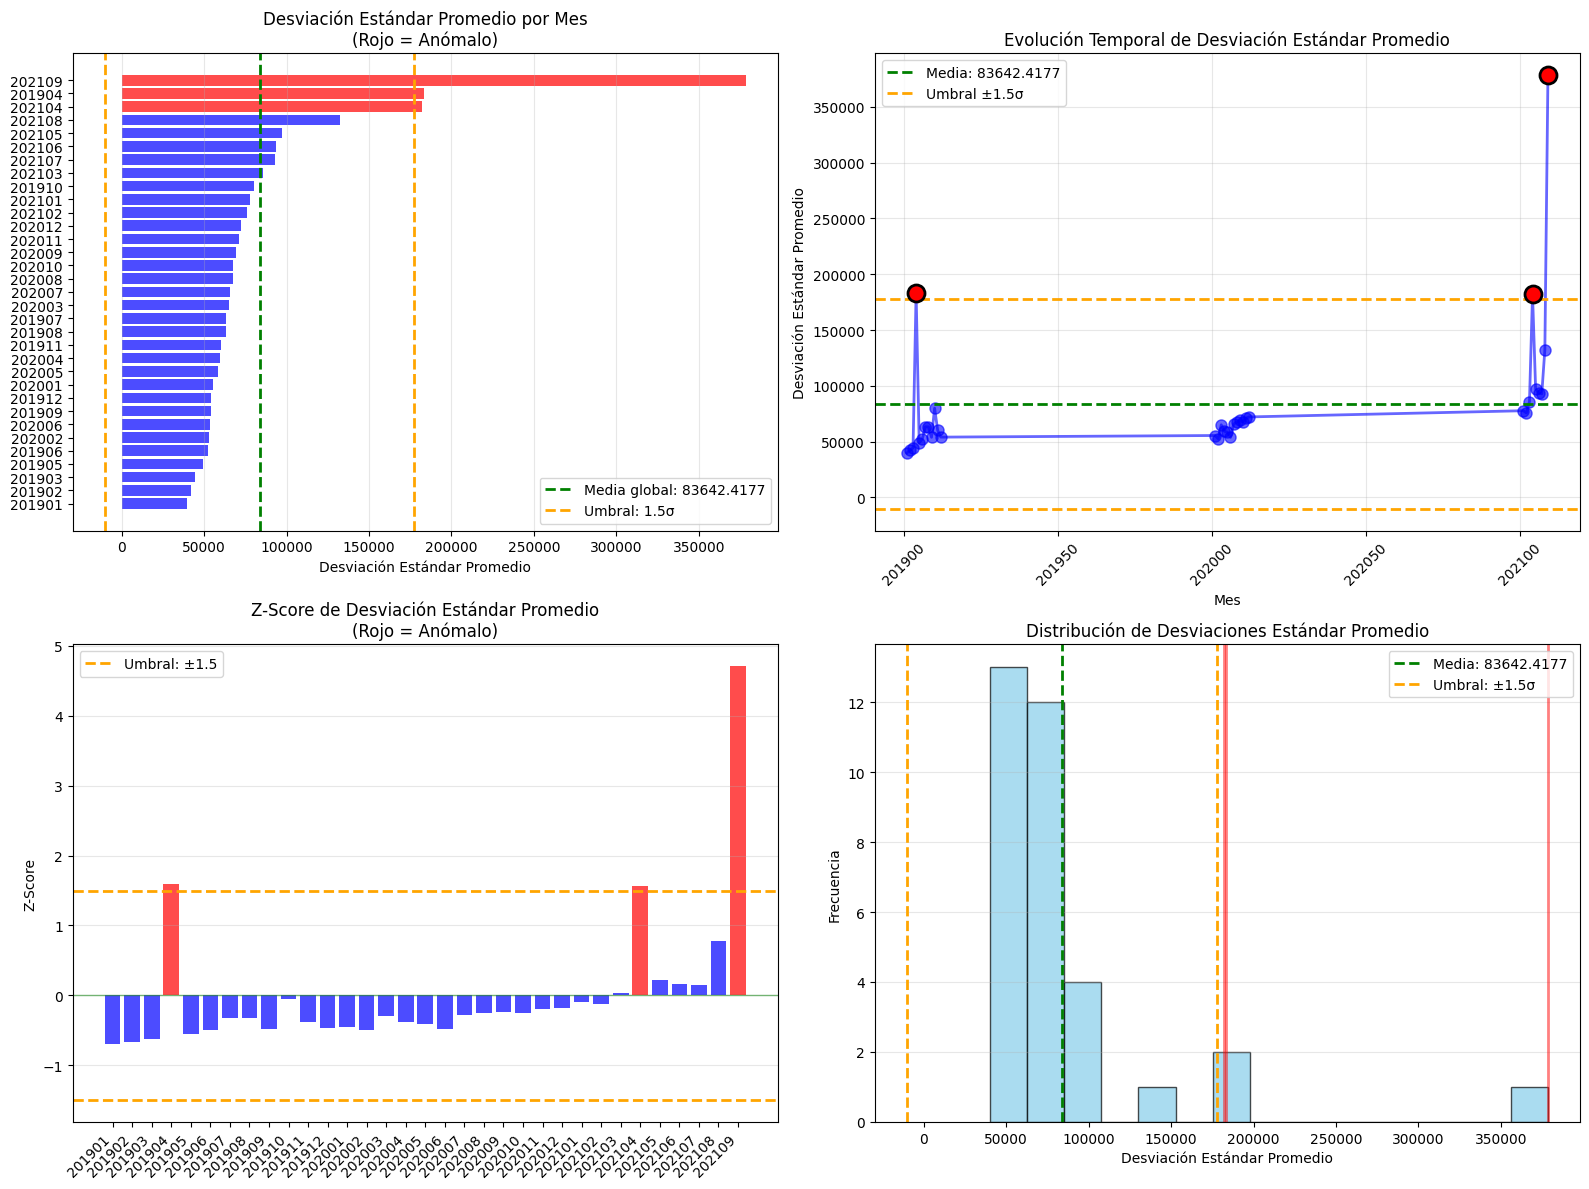

CPU times: user 20.3 s, sys: 79.3 ms, total: 20.4 s
Wall time: 4.27 s


In [6]:
%%time
# =========================
# 3.1) Detección de meses anómalos usando desviación estándar promedio
# =========================

# Excluir columnas no numéricas o de metadata
EXCLUDE_ANOMALY = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Obtener columnas numéricas (sin lags aún)
num_cols_base = [c for c, dt in zip(df.columns, df.dtypes)
                 if c not in EXCLUDE_ANOMALY and dt.is_numeric()]

print(f"Analizando {len(num_cols_base)} variables numéricas")
print(f"Meses disponibles: {sorted(df['foto_mes'].unique().to_list())}")

# Calcular desviación estándar por mes para cada variable
std_por_mes = (
    df.lazy()
    .group_by("foto_mes")
    .agg([
        *[pl.col(c).std().alias(f"{c}_std") for c in num_cols_base]
    ])
    .sort("foto_mes")
    .collect()
)

# Convertir a pandas para facilitar cálculos
std_df = std_por_mes.to_pandas()
meses = std_df["foto_mes"].values
std_df = std_df.drop(columns=["foto_mes"])

# Calcular la desviación estándar promedio de todas las variables para cada mes
std_promedio_por_mes = std_df.mean(axis=1)

# Crear DataFrame con resultados
anomaly_results = pd.DataFrame({
    "foto_mes": meses,
    "std_promedio": std_promedio_por_mes.values,
})

# Calcular estadísticas globales para identificar anomalías
media_std_global = std_promedio_por_mes.mean()
std_std_global = std_promedio_por_mes.std()

# Calcular z-score para cada mes (cuántas desviaciones estándar se desvía del promedio)
anomaly_results["z_score"] = (
    (anomaly_results["std_promedio"] - media_std_global) / (std_std_global + 1e-10)
)

# Identificar meses anómalos: aquellos con z-score absoluto > 1.5 (umbral estándar)
umbral_zscore = 1.5
anomaly_results["es_anomalo"] = np.abs(anomaly_results["z_score"]) > umbral_zscore

# Ordenar por desviación estándar promedio (descendente)
anomaly_results = anomaly_results.sort_values("std_promedio", ascending=False)

print("\n" + "="*70)
print("ANÁLISIS DE DESVIACIÓN ESTÁNDAR PROMEDIO POR MES")
print("="*70)
print(f"\nDesviación estándar promedio global: {media_std_global:.4f}")
print(f"Desviación estándar de las desviaciones estándar: {std_std_global:.4f}")
print(f"Umbral de anomalía (z-score > {umbral_zscore}): {media_std_global + umbral_zscore * std_std_global:.4f}")

print("\n" + "="*70)
print("MESES ORDENADOS POR DESVIACIÓN ESTÁNDAR PROMEDIO (mayor a menor)")
print("="*70)
print(anomaly_results[["foto_mes", "std_promedio", "z_score", "es_anomalo"]].to_string(index=False))

# Identificar meses anómalos
meses_anomalos = anomaly_results[anomaly_results["es_anomalo"] == True]["foto_mes"].tolist()

print("\n" + "="*70)
print("MESES ANÓMALOS DETECTADOS")
print("="*70)
if meses_anomalos:
    print(f"\n⚠️  MESES IDENTIFICADOS COMO ANÓMALOS: {meses_anomalos}")
    print(f"\nTotal de meses anómalos: {len(meses_anomalos)}")
    print(f"\nDetalles de meses anómalos:")
    for mes in meses_anomalos:
        row = anomaly_results[anomaly_results["foto_mes"] == mes].iloc[0]
        print(f"\n  📅 Mes {mes}:")
        print(f"     - Desviación estándar promedio: {row['std_promedio']:.4f}")
        print(f"     - Z-score: {row['z_score']:.4f}")
        print(f"     - Desviación respecto al promedio: {row['z_score'] * std_std_global:.4f}")
else:
    print("\n✅ No se detectaron meses anómalos con el umbral establecido.")
    print(f"   (Ningún mes tiene |z-score| > {umbral_zscore})")

print("\n" + "="*70)

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Desviación estándar promedio por mes (barras)
ax1 = axes[0, 0]
colors = ['red' if x else 'blue' for x in anomaly_results["es_anomalo"]]
ax1.barh(range(len(anomaly_results)), anomaly_results["std_promedio"].values, color=colors, alpha=0.7)
ax1.set_yticks(range(len(anomaly_results)))
ax1.set_yticklabels(anomaly_results["foto_mes"].values)
ax1.set_xlabel("Desviación Estándar Promedio")
ax1.set_title("Desviación Estándar Promedio por Mes\n(Rojo = Anómalo)")
ax1.axvline(media_std_global, color='green', linestyle='--', linewidth=2, label=f'Media global: {media_std_global:.4f}')
ax1.axvline(media_std_global + umbral_zscore * std_std_global, color='orange', linestyle='--', linewidth=2, label=f'Umbral: {umbral_zscore}σ')
ax1.axvline(media_std_global - umbral_zscore * std_std_global, color='orange', linestyle='--', linewidth=2)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.legend()

# 2. Desviación estándar promedio por mes (línea temporal)
ax2 = axes[0, 1]
anomaly_sorted = anomaly_results.sort_values("foto_mes")
colors_line = ['red' if x else 'blue' for x in anomaly_sorted["es_anomalo"]]
ax2.plot(anomaly_sorted["foto_mes"], anomaly_sorted["std_promedio"], 
         marker='o', linewidth=2, markersize=8, color='blue', alpha=0.6)
# Marcar puntos anómalos en rojo
for i, (mes, std_val, is_anomalo) in enumerate(zip(anomaly_sorted["foto_mes"], 
                                                     anomaly_sorted["std_promedio"], 
                                                     anomaly_sorted["es_anomalo"])):
    if is_anomalo:
        ax2.scatter(mes, std_val, s=150, c='red', marker='o', zorder=5, edgecolors='black', linewidth=2)
ax2.axhline(media_std_global, color='green', linestyle='--', linewidth=2, label=f'Media: {media_std_global:.4f}')
ax2.axhline(media_std_global + umbral_zscore * std_std_global, color='orange', linestyle='--', linewidth=2, label=f'Umbral ±{umbral_zscore}σ')
ax2.axhline(media_std_global - umbral_zscore * std_std_global, color='orange', linestyle='--', linewidth=2)
ax2.set_xlabel("Mes")
ax2.set_ylabel("Desviación Estándar Promedio")
ax2.set_title("Evolución Temporal de Desviación Estándar Promedio")
ax2.grid(alpha=0.3)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

# 3. Z-score por mes
ax3 = axes[1, 0]
colors_z = ['red' if x else 'blue' for x in anomaly_sorted["es_anomalo"]]
ax3.bar(range(len(anomaly_sorted)), anomaly_sorted["z_score"].values, color=colors_z, alpha=0.7)
ax3.set_xticks(range(len(anomaly_sorted)))
ax3.set_xticklabels(anomaly_sorted["foto_mes"].values, rotation=45, ha='right')
ax3.set_ylabel("Z-Score")
ax3.set_title("Z-Score de Desviación Estándar Promedio\n(Rojo = Anómalo)")
ax3.axhline(umbral_zscore, color='orange', linestyle='--', linewidth=2, label=f'Umbral: ±{umbral_zscore}')
ax3.axhline(-umbral_zscore, color='orange', linestyle='--', linewidth=2)
ax3.axhline(0, color='green', linestyle='-', linewidth=1, alpha=0.5)
ax3.grid(axis='y', alpha=0.3)
ax3.legend()

# 4. Distribución de desviaciones estándar promedio
ax4 = axes[1, 1]
ax4.hist(anomaly_results["std_promedio"], bins=15, edgecolor='black', alpha=0.7, color='skyblue')
ax4.axvline(media_std_global, color='green', linestyle='--', linewidth=2, label=f'Media: {media_std_global:.4f}')
ax4.axvline(media_std_global + umbral_zscore * std_std_global, color='orange', linestyle='--', linewidth=2, label=f'Umbral: ±{umbral_zscore}σ')
ax4.axvline(media_std_global - umbral_zscore * std_std_global, color='orange', linestyle='--', linewidth=2)
# Marcar meses anómalos
for mes_anomalo in meses_anomalos:
    std_val = anomaly_results[anomaly_results["foto_mes"] == mes_anomalo]["std_promedio"].iloc[0]
    ax4.axvline(std_val, color='red', linestyle='-', linewidth=2, alpha=0.5)
ax4.set_xlabel("Desviación Estándar Promedio")
ax4.set_ylabel("Frecuencia")
ax4.set_title("Distribución de Desviaciones Estándar Promedio")
ax4.grid(axis='y', alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()


ANÁLISIS DETALLADO DEL MES 201904

📊 RESUMEN DEL MES 201904
   - Desviación estándar promedio: 183123.4433
   - Desviación estándar promedio de otros meses: 80439.9508
   - Diferencia: 102683.4926

TOP 20 VARIABLES CON MAYOR Z-SCORE (más anómalas en 201904)
                          variable  std_mes_201904  std_promedio_otros_meses  porcentaje_desviacion    z_score
 ctarjeta_visa_debitos_automaticos    0.000000e+00              3.207538e+00            -100.000000 -12.253481
       Master_mfinanciacion_limite    1.193657e+07              1.013368e+06            1077.911315   4.820799
         Visa_mfinanciacion_limite    8.887822e+06              9.838721e+05             803.351333   4.803074
mttarjeta_visa_debitos_automaticos    0.000000e+00              1.079258e+04            -100.000000  -4.276094
        chomebanking_transacciones    2.268248e+02              6.705061e+01             238.288926   4.104608
                  cpagodeservicios    1.769242e+00              5.833617e-01

<timed exec>:240: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


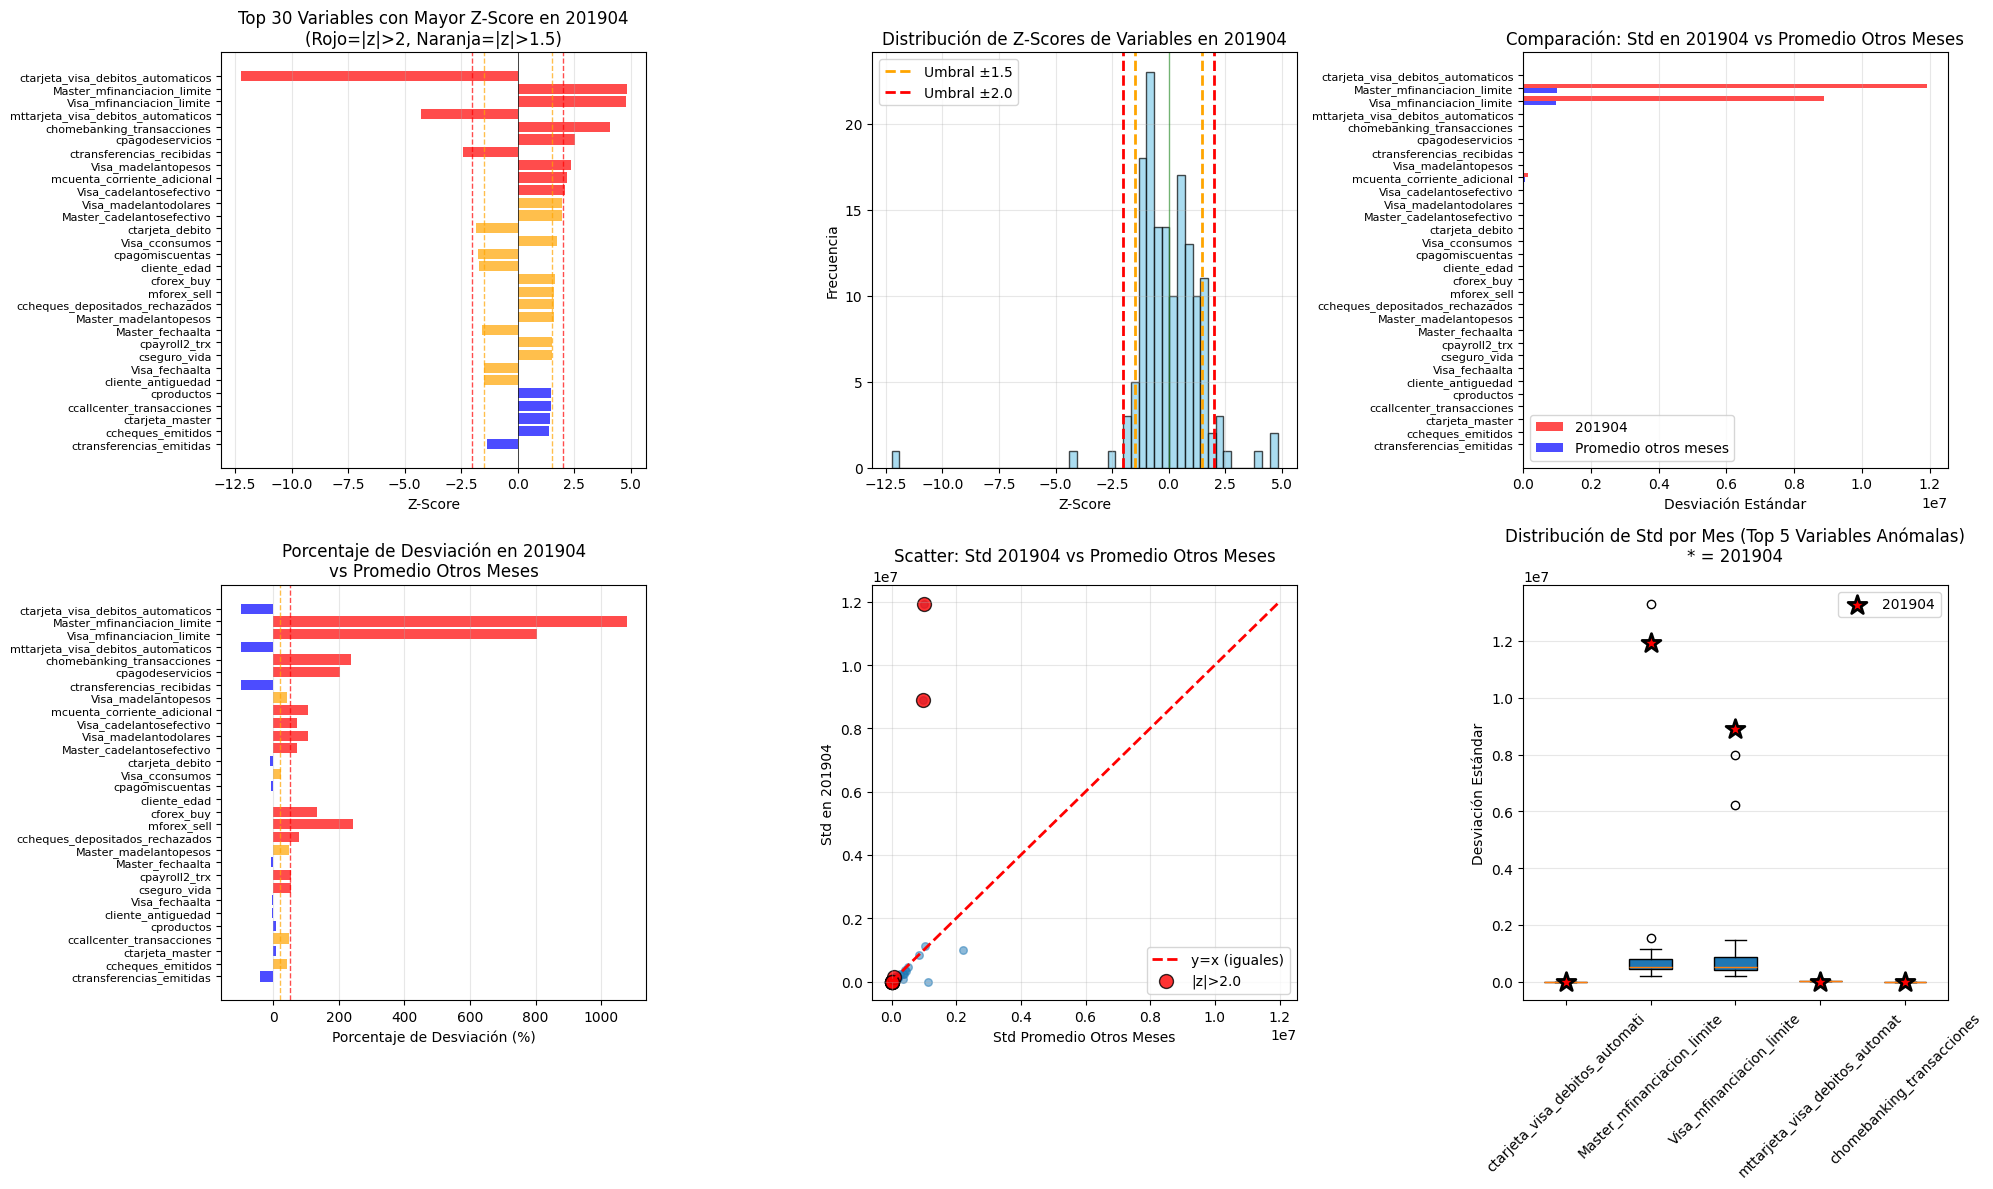


RESUMEN FINAL

✅ Total de variables analizadas: 152
⚠️  Variables con |z-score| > 2.0: 10 (6.6%)
📈 Variables con |z-score| > 1.5: 25 (16.4%)

💡 El mes 201904 tiene alta variabilidad principalmente en:
   - Visa: z-score promedio = 1.59

CPU times: user 20.5 s, sys: 70.7 ms, total: 20.6 s
Wall time: 3.98 s


In [7]:
%%time
# =========================
# 3.1.1) Análisis detallado del mes 201904 - ¿Qué causa la alta variabilidad?
# =========================

mes_analizar = 201904

print("="*80)
print(f"ANÁLISIS DETALLADO DEL MES {mes_analizar}")
print("="*80)

# Excluir columnas no numéricas o de metadata
EXCLUDE_ANOMALY = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Obtener columnas numéricas (sin lags aún)
num_cols_base = [c for c, dt in zip(df.columns, df.dtypes)
                 if c not in EXCLUDE_ANOMALY and dt.is_numeric()]

# Calcular desviación estándar por mes para cada variable
std_por_mes_detalle = (
    df.lazy()
    .group_by("foto_mes")
    .agg([
        *[pl.col(c).std().alias(f"{c}_std") for c in num_cols_base]
    ])
    .sort("foto_mes")
    .collect()
)

# Convertir a pandas
std_df_detalle = std_por_mes_detalle.to_pandas()
meses_detalle = std_df_detalle["foto_mes"].values

# Obtener desviación estándar del mes a analizar
if mes_analizar not in meses_detalle:
    print(f"\n❌ El mes {mes_analizar} no está en el dataset.")
else:
    # Filtrar datos del mes a analizar
    std_mes_analizar = std_df_detalle[std_df_detalle["foto_mes"] == mes_analizar].iloc[0]
    
    # Calcular desviación estándar promedio de todos los meses (excluyendo el mes anómalo)
    meses_normales = [m for m in meses_detalle if m != mes_analizar]
    std_df_normales = std_df_detalle[std_df_detalle["foto_mes"].isin(meses_normales)]
    
    # Calcular media y std de desviaciones estándar para cada variable
    std_media_por_variable = std_df_normales.drop(columns=["foto_mes"]).mean()
    std_std_por_variable = std_df_normales.drop(columns=["foto_mes"]).std()
    
    # Crear DataFrame con análisis detallado
    analisis_detalle = []
    for col in num_cols_base:
        col_std = f"{col}_std"
        std_val_mes = std_mes_analizar[col_std]
        std_media_global = std_media_por_variable[col_std]
        std_std_global = std_std_por_variable[col_std]
        
        if std_std_global > 0:
            z_score_var = (std_val_mes - std_media_global) / std_std_global
            desviacion_abs = std_val_mes - std_media_global
            porcentaje_desviacion = (desviacion_abs / (std_media_global + 1e-10)) * 100
        else:
            z_score_var = 0
            desviacion_abs = std_val_mes - std_media_global
            porcentaje_desviacion = 0
        
        analisis_detalle.append({
            "variable": col,
            "std_mes_201904": std_val_mes,
            "std_promedio_otros_meses": std_media_global,
            "desviacion_absoluta": desviacion_abs,
            "porcentaje_desviacion": porcentaje_desviacion,
            "z_score": z_score_var
        })
    
    df_analisis = pd.DataFrame(analisis_detalle)
    
    # Ordenar por z-score absoluto (las más anómalas primero)
    df_analisis["z_score_abs"] = df_analisis["z_score"].abs()
    df_analisis = df_analisis.sort_values("z_score_abs", ascending=False)
    
    print(f"\n📊 RESUMEN DEL MES {mes_analizar}")
    print(f"   - Desviación estándar promedio: {df_analisis['std_mes_201904'].mean():.4f}")
    print(f"   - Desviación estándar promedio de otros meses: {df_analisis['std_promedio_otros_meses'].mean():.4f}")
    print(f"   - Diferencia: {df_analisis['std_mes_201904'].mean() - df_analisis['std_promedio_otros_meses'].mean():.4f}")
    
    # Top 20 variables más problemáticas
    print("\n" + "="*80)
    print("TOP 20 VARIABLES CON MAYOR Z-SCORE (más anómalas en 201904)")
    print("="*80)
    top_20 = df_analisis.head(20)
    print(top_20[["variable", "std_mes_201904", "std_promedio_otros_meses", 
                  "porcentaje_desviacion", "z_score"]].to_string(index=False))
    
    # Variables con z-score > 2 (muy anómalas)
    vars_muy_anomalas = df_analisis[df_analisis["z_score_abs"] > 2.0]
    print(f"\n⚠️  Variables con |z-score| > 2.0: {len(vars_muy_anomalas)}")
    if len(vars_muy_anomalas) > 0:
        print("\nVariables muy anómalas:")
        for idx, row in vars_muy_anomalas.head(10).iterrows():
            print(f"   - {row['variable']}: z-score={row['z_score']:.2f}, "
                  f"desviación={row['porcentaje_desviacion']:.1f}%")
    
    # Variables con z-score > 1.5 (anómalas)
    vars_anomalas = df_analisis[df_analisis["z_score_abs"] > 1.5]
    print(f"\n📈 Variables con |z-score| > 1.5: {len(vars_anomalas)}")
    
    # Estadísticas por categoría de variables
    print("\n" + "="*80)
    print("ANÁLISIS POR CATEGORÍAS DE VARIABLES")
    print("="*80)
    
    # Identificar categorías comunes
    categorias = {
        "Montos (m_)": [c for c in num_cols_base if c.startswith("m_")],
        "Contadores (c_)": [c for c in num_cols_base if c.startswith("c") and not c.startswith("m_")],
        "Visa": [c for c in num_cols_base if "Visa" in c or "visa" in c],
        "Master": [c for c in num_cols_base if "Master" in c or "master" in c],
        "Payroll": [c for c in num_cols_base if "payroll" in c.lower()],
        "Prestamos": [c for c in num_cols_base if "prestamo" in c.lower()],
        "Inversiones": [c for c in num_cols_base if "inversion" in c.lower() or "plazo_fijo" in c.lower()],
    }
    
    for cat_name, vars_cat in categorias.items():
        if len(vars_cat) > 0:
            df_cat = df_analisis[df_analisis["variable"].isin(vars_cat)]
            if len(df_cat) > 0:
                z_score_promedio = df_cat["z_score_abs"].mean()
                vars_anomalas_cat = len(df_cat[df_cat["z_score_abs"] > 1.5])
                print(f"\n{cat_name}:")
                print(f"   - Variables en categoría: {len(df_cat)}")
                print(f"   - Z-score promedio (abs): {z_score_promedio:.2f}")
                print(f"   - Variables anómalas (|z|>1.5): {vars_anomalas_cat}")
                if vars_anomalas_cat > 0:
                    top_cat = df_cat.nlargest(3, "z_score_abs")
                    print(f"   - Top 3 más anómalas:")
                    for _, row in top_cat.iterrows():
                        print(f"     * {row['variable']}: z={row['z_score']:.2f}")
    
    # Visualizaciones
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # 1. Top 30 variables con mayor z-score
    ax1 = axes[0, 0]
    top_30 = df_analisis.head(30)
    colors = ['red' if abs(z) > 2 else 'orange' if abs(z) > 1.5 else 'blue' 
              for z in top_30["z_score"]]
    ax1.barh(range(len(top_30)), top_30["z_score"].values, color=colors, alpha=0.7)
    ax1.set_yticks(range(len(top_30)))
    ax1.set_yticklabels(top_30["variable"].values, fontsize=8)
    ax1.set_xlabel("Z-Score")
    ax1.set_title(f"Top 30 Variables con Mayor Z-Score en {mes_analizar}\n(Rojo=|z|>2, Naranja=|z|>1.5)")
    ax1.axvline(1.5, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax1.axvline(-1.5, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax1.axvline(2.0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax1.axvline(-2.0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax1.axvline(0, color='black', linestyle='-', linewidth=0.5)
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # 2. Distribución de z-scores
    ax2 = axes[0, 1]
    ax2.hist(df_analisis["z_score"], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    ax2.axvline(1.5, color='orange', linestyle='--', linewidth=2, label='Umbral ±1.5')
    ax2.axvline(-1.5, color='orange', linestyle='--', linewidth=2)
    ax2.axvline(2.0, color='red', linestyle='--', linewidth=2, label='Umbral ±2.0')
    ax2.axvline(-2.0, color='red', linestyle='--', linewidth=2)
    ax2.axvline(0, color='green', linestyle='-', linewidth=1, alpha=0.5)
    ax2.set_xlabel("Z-Score")
    ax2.set_ylabel("Frecuencia")
    ax2.set_title(f"Distribución de Z-Scores de Variables en {mes_analizar}")
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # 3. Comparación: std en 201904 vs promedio otros meses (top 30)
    ax3 = axes[0, 2]
    top_30_comp = df_analisis.head(30)
    x_pos = np.arange(len(top_30_comp))
    width = 0.35
    ax3.barh(x_pos - width/2, top_30_comp["std_mes_201904"].values, width, 
             label=f'201904', color='red', alpha=0.7)
    ax3.barh(x_pos + width/2, top_30_comp["std_promedio_otros_meses"].values, width, 
             label='Promedio otros meses', color='blue', alpha=0.7)
    ax3.set_yticks(x_pos)
    ax3.set_yticklabels(top_30_comp["variable"].values, fontsize=8)
    ax3.set_xlabel("Desviación Estándar")
    ax3.set_title(f"Comparación: Std en {mes_analizar} vs Promedio Otros Meses")
    ax3.legend()
    ax3.invert_yaxis()
    ax3.grid(axis='x', alpha=0.3)
    
    # 4. Porcentaje de desviación (top 30)
    ax4 = axes[1, 0]
    top_30_pct = df_analisis.head(30)
    colors_pct = ['red' if p > 50 else 'orange' if p > 20 else 'blue' 
                  for p in top_30_pct["porcentaje_desviacion"]]
    ax4.barh(range(len(top_30_pct)), top_30_pct["porcentaje_desviacion"].values, 
             color=colors_pct, alpha=0.7)
    ax4.set_yticks(range(len(top_30_pct)))
    ax4.set_yticklabels(top_30_pct["variable"].values, fontsize=8)
    ax4.set_xlabel("Porcentaje de Desviación (%)")
    ax4.set_title(f"Porcentaje de Desviación en {mes_analizar}\nvs Promedio Otros Meses")
    ax4.axvline(20, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax4.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax4.invert_yaxis()
    ax4.grid(axis='x', alpha=0.3)
    
    # 5. Scatter: std 201904 vs std promedio otros meses
    ax5 = axes[1, 1]
    ax5.scatter(df_analisis["std_promedio_otros_meses"], 
                df_analisis["std_mes_201904"], 
                alpha=0.5, s=30)
    # Línea y=x (donde estarían si fueran iguales)
    max_val = max(df_analisis["std_promedio_otros_meses"].max(), 
                  df_analisis["std_mes_201904"].max())
    ax5.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='y=x (iguales)')
    # Marcar las más anómalas
    vars_extremas = df_analisis[df_analisis["z_score_abs"] > 2.0]
    if len(vars_extremas) > 0:
        ax5.scatter(vars_extremas["std_promedio_otros_meses"], 
                   vars_extremas["std_mes_201904"], 
                   color='red', s=100, alpha=0.8, label='|z|>2.0', edgecolors='black')
    ax5.set_xlabel("Std Promedio Otros Meses")
    ax5.set_ylabel(f"Std en {mes_analizar}")
    ax5.set_title(f"Scatter: Std {mes_analizar} vs Promedio Otros Meses")
    ax5.legend()
    ax5.grid(alpha=0.3)
    
    # 6. Boxplot de desviaciones estándar por mes (solo algunas variables clave)
    ax6 = axes[1, 2]
    # Seleccionar las 5 variables más anómalas
    top_5_vars = df_analisis.head(5)["variable"].tolist()
    # Preparar datos para boxplot
    data_boxplot = []
    labels_boxplot = []
    for var in top_5_vars:
        col_std = f"{var}_std"
        valores = std_df_detalle[col_std].values
        data_boxplot.append(valores)
        labels_boxplot.append(var[:30])  # Truncar nombres largos
    
    bp = ax6.boxplot(data_boxplot, labels=labels_boxplot, vert=True, patch_artist=True)
    # Colorear el box del mes 201904
    for i, var in enumerate(top_5_vars):
        col_std = f"{var}_std"
        std_val_201904 = std_mes_analizar[col_std]
        # Marcar el valor de 201904
        ax6.scatter([i+1], [std_val_201904], s=200, c='red', marker='*', 
                   zorder=10, edgecolors='black', linewidth=2, label='201904' if i == 0 else '')
    
    ax6.set_ylabel("Desviación Estándar")
    ax6.set_title("Distribución de Std por Mes (Top 5 Variables Anómalas)\n* = 201904")
    ax6.tick_params(axis='x', rotation=45)
    ax6.grid(axis='y', alpha=0.3)
    ax6.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Resumen final
    print("\n" + "="*80)
    print("RESUMEN FINAL")
    print("="*80)
    print(f"\n✅ Total de variables analizadas: {len(df_analisis)}")
    print(f"⚠️  Variables con |z-score| > 2.0: {len(vars_muy_anomalas)} ({len(vars_muy_anomalas)/len(df_analisis)*100:.1f}%)")
    print(f"📈 Variables con |z-score| > 1.5: {len(vars_anomalas)} ({len(vars_anomalas)/len(df_analisis)*100:.1f}%)")
    print(f"\n💡 El mes {mes_analizar} tiene alta variabilidad principalmente en:")
    if len(vars_muy_anomalas) > 0:
        top_categorias = []
        for cat_name, vars_cat in categorias.items():
            df_cat = df_analisis[df_analisis["variable"].isin(vars_cat)]
            if len(df_cat) > 0:
                z_prom = df_cat["z_score_abs"].mean()
                if z_prom > 1.5:
                    top_categorias.append((cat_name, z_prom))
        top_categorias.sort(key=lambda x: x[1], reverse=True)
        for cat, z_prom in top_categorias[:5]:
            print(f"   - {cat}: z-score promedio = {z_prom:.2f}")
    
    print("\n" + "="*80)


Analizando 152 variables numéricas con PSI
Meses disponibles: [201901, 201902, 201903, 201904, 201905, 201906, 201907, 201908, 201909, 201910, 201911, 201912, 202001, 202002, 202003, 202004, 202005, 202006, 202007, 202008, 202009, 202010, 202011, 202012, 202101, 202102, 202103, 202104, 202105, 202106, 202107, 202108, 202109]

Mes de referencia para PSI: 202005

ANÁLISIS DE PSI (Population Stability Index) POR MES

Mes de referencia: 202005
Umbral PSI para cambio moderado: 0.1
Umbral PSI para cambio significativo (anómalo): 0.25

MESES ORDENADOS POR PSI PROMEDIO (mayor a menor)
 foto_mes  psi_promedio  psi_maximo  variables_alto_psi categoria_psi  es_anomalo_psi
   202006      0.973330   30.127862                  16       Anómalo            True
   202010      0.303631   20.655078                   6       Anómalo            True
   202106      0.209330   11.500459                   5      Moderado           False
   202007      0.192249   21.805128                   2      Moderado   

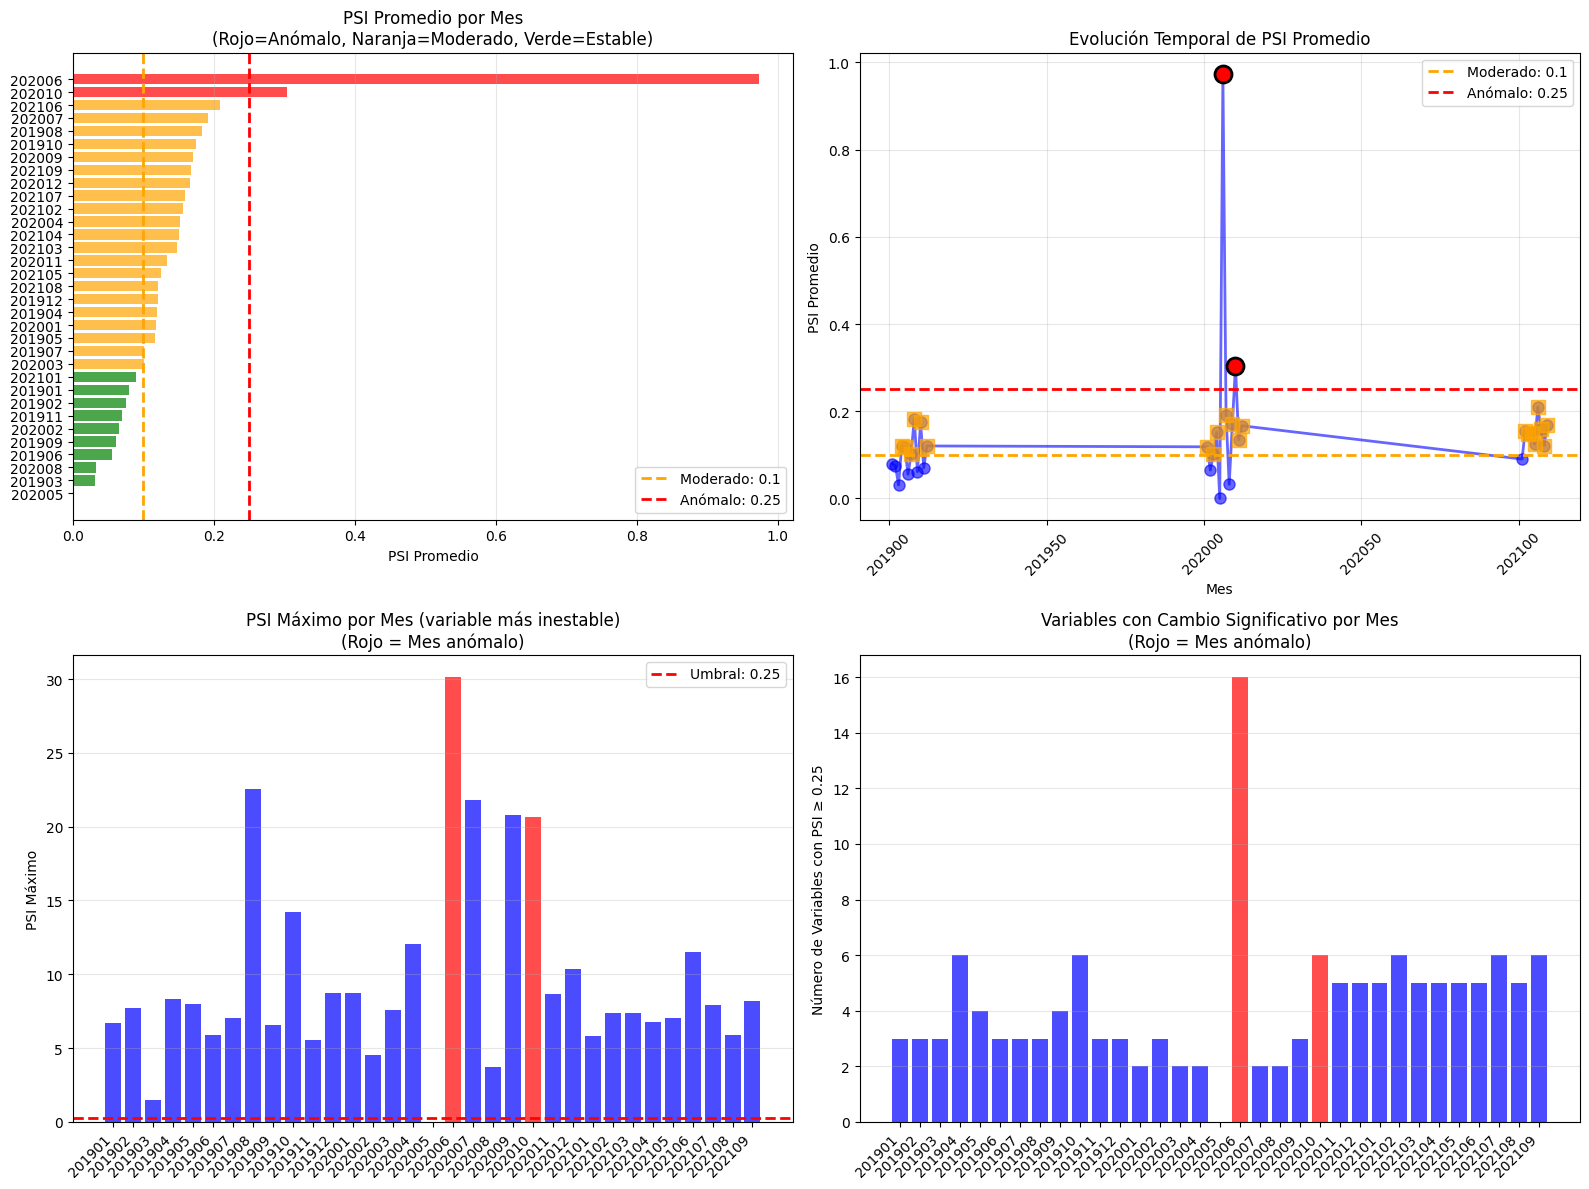

CPU times: user 28 s, sys: 5.72 s, total: 33.7 s
Wall time: 25.9 s


In [8]:
%%time
# =========================
# 3.2) Detección de meses anómalos usando PSI (Population Stability Index)
# =========================

def calculate_psi(expected, actual, bins=10):
    """
    Calcula el Population Stability Index (PSI) entre dos distribuciones.
    
    PSI mide la estabilidad de la distribución de una variable:
    - PSI < 0.1: Sin cambio significativo
    - 0.1 ≤ PSI < 0.25: Cambio moderado
    - PSI ≥ 0.25: Cambio significativo
    
    Args:
        expected: Distribución esperada (mes de referencia)
        actual: Distribución actual (mes a comparar)
        bins: Número de bins para discretizar
    
    Returns:
        PSI value
    """
    # Filtrar valores no nulos
    expected = expected[~np.isnan(expected)]
    actual = actual[~np.isnan(actual)]
    
    if len(expected) == 0 or len(actual) == 0:
        return np.nan
    
    # Crear bins basados en la distribución esperada
    min_val = min(expected.min(), actual.min())
    max_val = max(expected.max(), actual.max())
    
    # Evitar división por cero
    if max_val == min_val:
        return 0.0
    
    # Crear bins
    bin_edges = np.linspace(min_val, max_val, bins + 1)
    
    # Calcular frecuencias
    expected_counts, _ = np.histogram(expected, bins=bin_edges)
    actual_counts, _ = np.histogram(actual, bins=bin_edges)
    
    # Normalizar a proporciones
    expected_prop = expected_counts / (len(expected) + 1e-10)
    actual_prop = actual_counts / (len(actual) + 1e-10)
    
    # Evitar log(0)
    expected_prop = np.where(expected_prop == 0, 1e-10, expected_prop)
    actual_prop = np.where(actual_prop == 0, 1e-10, actual_prop)
    
    # Calcular PSI
    psi = np.sum((actual_prop - expected_prop) * np.log(actual_prop / expected_prop))
    
    return psi

# Excluir columnas no numéricas o de metadata
EXCLUDE_ANOMALY = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Obtener columnas numéricas (sin lags aún)
num_cols_base = [c for c, dt in zip(df.columns, df.dtypes)
                 if c not in EXCLUDE_ANOMALY and dt.is_numeric()]

print(f"Analizando {len(num_cols_base)} variables numéricas con PSI")
print(f"Meses disponibles: {sorted(df['foto_mes'].unique().to_list())}")

# Convertir a pandas para facilitar cálculos de PSI
df_pd = df.select(["foto_mes"] + num_cols_base).to_pandas()
meses = sorted(df_pd["foto_mes"].unique())

# Elegir mes de referencia: usar la mediana de todos los meses (mes del medio)
mes_referencia = meses[len(meses) // 2]
print(f"\nMes de referencia para PSI: {mes_referencia}")

# Obtener datos del mes de referencia
df_referencia = df_pd[df_pd["foto_mes"] == mes_referencia]

# Calcular PSI para cada variable y cada mes
psi_results = []

for mes in meses:
    if mes == mes_referencia:
        # El mes de referencia tiene PSI = 0
        psi_results.append({
            "foto_mes": mes,
            "psi_promedio": 0.0,
            "psi_maximo": 0.0,
            "variables_alto_psi": 0
        })
        continue
    
    df_mes = df_pd[df_pd["foto_mes"] == mes]
    psi_por_variable = []
    
    for col in num_cols_base:
        try:
            psi_val = calculate_psi(
                df_referencia[col].values,
                df_mes[col].values,
                bins=10
            )
            if not np.isnan(psi_val):
                psi_por_variable.append(psi_val)
        except Exception as e:
            # Si hay error, omitir esta variable
            continue
    
    if len(psi_por_variable) > 0:
        psi_promedio = np.mean(psi_por_variable)
        psi_maximo = np.max(psi_por_variable)
        # Contar variables con PSI >= 0.25 (cambio significativo)
        variables_alto_psi = sum(1 for p in psi_por_variable if p >= 0.25)
    else:
        psi_promedio = np.nan
        psi_maximo = np.nan
        variables_alto_psi = 0
    
    psi_results.append({
        "foto_mes": mes,
        "psi_promedio": psi_promedio,
        "psi_maximo": psi_maximo,
        "variables_alto_psi": variables_alto_psi
    })

# Crear DataFrame con resultados
psi_df = pd.DataFrame(psi_results)

# Identificar meses anómalos basado en PSI
# Umbrales de PSI:
# - PSI < 0.1: Sin cambio significativo
# - 0.1 ≤ PSI < 0.25: Cambio moderado
# - PSI ≥ 0.25: Cambio significativo (anómalo)
umbral_psi_anomalo = 0.25
umbral_psi_moderado = 0.1

psi_df["categoria_psi"] = pd.cut(
    psi_df["psi_promedio"],
    bins=[-np.inf, umbral_psi_moderado, umbral_psi_anomalo, np.inf],
    labels=["Estable", "Moderado", "Anómalo"]
)

psi_df["es_anomalo_psi"] = psi_df["psi_promedio"] >= umbral_psi_anomalo

# Ordenar por PSI promedio (descendente)
psi_df = psi_df.sort_values("psi_promedio", ascending=False)

print("\n" + "="*70)
print("ANÁLISIS DE PSI (Population Stability Index) POR MES")
print("="*70)
print(f"\nMes de referencia: {mes_referencia}")
print(f"Umbral PSI para cambio moderado: {umbral_psi_moderado}")
print(f"Umbral PSI para cambio significativo (anómalo): {umbral_psi_anomalo}")

print("\n" + "="*70)
print("MESES ORDENADOS POR PSI PROMEDIO (mayor a menor)")
print("="*70)
print(psi_df[["foto_mes", "psi_promedio", "psi_maximo", "variables_alto_psi", "categoria_psi", "es_anomalo_psi"]].to_string(index=False))

# Identificar meses anómalos
meses_anomalos_psi = psi_df[psi_df["es_anomalo_psi"] == True]["foto_mes"].tolist()

print("\n" + "="*70)
print("MESES ANÓMALOS DETECTADOS POR PSI")
print("="*70)
if meses_anomalos_psi:
    print(f"\n⚠️  MESES IDENTIFICADOS COMO ANÓMALOS (PSI ≥ {umbral_psi_anomalo}): {meses_anomalos_psi}")
    print(f"\nTotal de meses anómalos: {len(meses_anomalos_psi)}")
    print(f"\nDetalles de meses anómalos:")
    for mes in meses_anomalos_psi:
        row = psi_df[psi_df["foto_mes"] == mes].iloc[0]
        print(f"\n  📅 Mes {mes}:")
        print(f"     - PSI promedio: {row['psi_promedio']:.4f}")
        print(f"     - PSI máximo: {row['psi_maximo']:.4f}")
        print(f"     - Variables con PSI ≥ 0.25: {row['variables_alto_psi']}")
        print(f"     - Categoría: {row['categoria_psi']}")
else:
    print(f"\n✅ No se detectaron meses anómalos con PSI ≥ {umbral_psi_anomalo}.")
    print("   Todos los meses tienen cambios moderados o estables respecto al mes de referencia.")

# Meses con cambios moderados
meses_moderados = psi_df[
    (psi_df["psi_promedio"] >= umbral_psi_moderado) & 
    (psi_df["psi_promedio"] < umbral_psi_anomalo)
]["foto_mes"].tolist()

if meses_moderados:
    print(f"\n📊 Meses con cambios moderados (0.1 ≤ PSI < 0.25): {meses_moderados}")

print("\n" + "="*70)

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. PSI promedio por mes (barras)
ax1 = axes[0, 0]
colors = ['red' if x else 'orange' if 0.1 <= y < 0.25 else 'green' 
          for x, y in zip(psi_df["es_anomalo_psi"], psi_df["psi_promedio"])]
ax1.barh(range(len(psi_df)), psi_df["psi_promedio"].values, color=colors, alpha=0.7)
ax1.set_yticks(range(len(psi_df)))
ax1.set_yticklabels(psi_df["foto_mes"].values)
ax1.set_xlabel("PSI Promedio")
ax1.set_title("PSI Promedio por Mes\n(Rojo=Anómalo, Naranja=Moderado, Verde=Estable)")
ax1.axvline(umbral_psi_moderado, color='orange', linestyle='--', linewidth=2, label=f'Moderado: {umbral_psi_moderado}')
ax1.axvline(umbral_psi_anomalo, color='red', linestyle='--', linewidth=2, label=f'Anómalo: {umbral_psi_anomalo}')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.legend()

# 2. PSI promedio por mes (línea temporal)
ax2 = axes[0, 1]
psi_sorted = psi_df.sort_values("foto_mes")
colors_line = ['red' if x else 'orange' if 0.1 <= y < 0.25 else 'blue'
               for x, y in zip(psi_sorted["es_anomalo_psi"], psi_sorted["psi_promedio"])]
ax2.plot(psi_sorted["foto_mes"], psi_sorted["psi_promedio"], 
         marker='o', linewidth=2, markersize=8, color='blue', alpha=0.6)
# Marcar puntos anómalos en rojo
for i, (mes, psi_val, is_anomalo) in enumerate(zip(psi_sorted["foto_mes"], 
                                                     psi_sorted["psi_promedio"], 
                                                     psi_sorted["es_anomalo_psi"])):
    if is_anomalo:
        ax2.scatter(mes, psi_val, s=150, c='red', marker='o', zorder=5, edgecolors='black', linewidth=2)
    elif 0.1 <= psi_val < 0.25:
        ax2.scatter(mes, psi_val, s=100, c='orange', marker='s', zorder=5, alpha=0.7)
ax2.axhline(umbral_psi_moderado, color='orange', linestyle='--', linewidth=2, label=f'Moderado: {umbral_psi_moderado}')
ax2.axhline(umbral_psi_anomalo, color='red', linestyle='--', linewidth=2, label=f'Anómalo: {umbral_psi_anomalo}')
ax2.set_xlabel("Mes")
ax2.set_ylabel("PSI Promedio")
ax2.set_title("Evolución Temporal de PSI Promedio")
ax2.grid(alpha=0.3)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

# 3. PSI máximo por mes
ax3 = axes[1, 0]
colors_max = ['red' if x else 'blue' for x in psi_sorted["es_anomalo_psi"]]
ax3.bar(range(len(psi_sorted)), psi_sorted["psi_maximo"].values, color=colors_max, alpha=0.7)
ax3.set_xticks(range(len(psi_sorted)))
ax3.set_xticklabels(psi_sorted["foto_mes"].values, rotation=45, ha='right')
ax3.set_ylabel("PSI Máximo")
ax3.set_title("PSI Máximo por Mes (variable más inestable)\n(Rojo = Mes anómalo)")
ax3.axhline(umbral_psi_anomalo, color='red', linestyle='--', linewidth=2, label=f'Umbral: {umbral_psi_anomalo}')
ax3.grid(axis='y', alpha=0.3)
ax3.legend()

# 4. Número de variables con PSI alto por mes
ax4 = axes[1, 1]
colors_vars = ['red' if x else 'blue' for x in psi_sorted["es_anomalo_psi"]]
ax4.bar(range(len(psi_sorted)), psi_sorted["variables_alto_psi"].values, color=colors_vars, alpha=0.7)
ax4.set_xticks(range(len(psi_sorted)))
ax4.set_xticklabels(psi_sorted["foto_mes"].values, rotation=45, ha='right')
ax4.set_ylabel("Número de Variables con PSI ≥ 0.25")
ax4.set_title("Variables con Cambio Significativo por Mes\n(Rojo = Mes anómalo)")
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


ANÁLISIS DETALLADO DE MESES: [201904, 202006, 202010]

ANÁLISIS DEL MES 201904

📊 RESUMEN DEL MES 201904
   - Desviación estándar promedio: 183123.4433
   - Desviación estándar promedio de otros meses: 81754.1532
   - Diferencia: 101369.2901

TOP 20 VARIABLES CON MAYOR Z-SCORE (más anómalas en 201904)
                          variable  std_mes_201904  std_promedio_otros_meses  porcentaje_desviacion    z_score
 ctarjeta_visa_debitos_automaticos    0.000000e+00              3.218029e+00            -100.000000 -12.055644
       Master_mfinanciacion_limite    1.193657e+07              1.042332e+06            1045.179423   4.656460
         Visa_mfinanciacion_limite    8.887822e+06              1.015844e+06             774.920182   4.640359
        chomebanking_transacciones    2.268248e+02              6.883823e+01             229.504126   4.141581
mttarjeta_visa_debitos_automaticos    0.000000e+00              1.079952e+04            -100.000000  -4.140240
                  cpagodeservic

<timed exec>:295: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


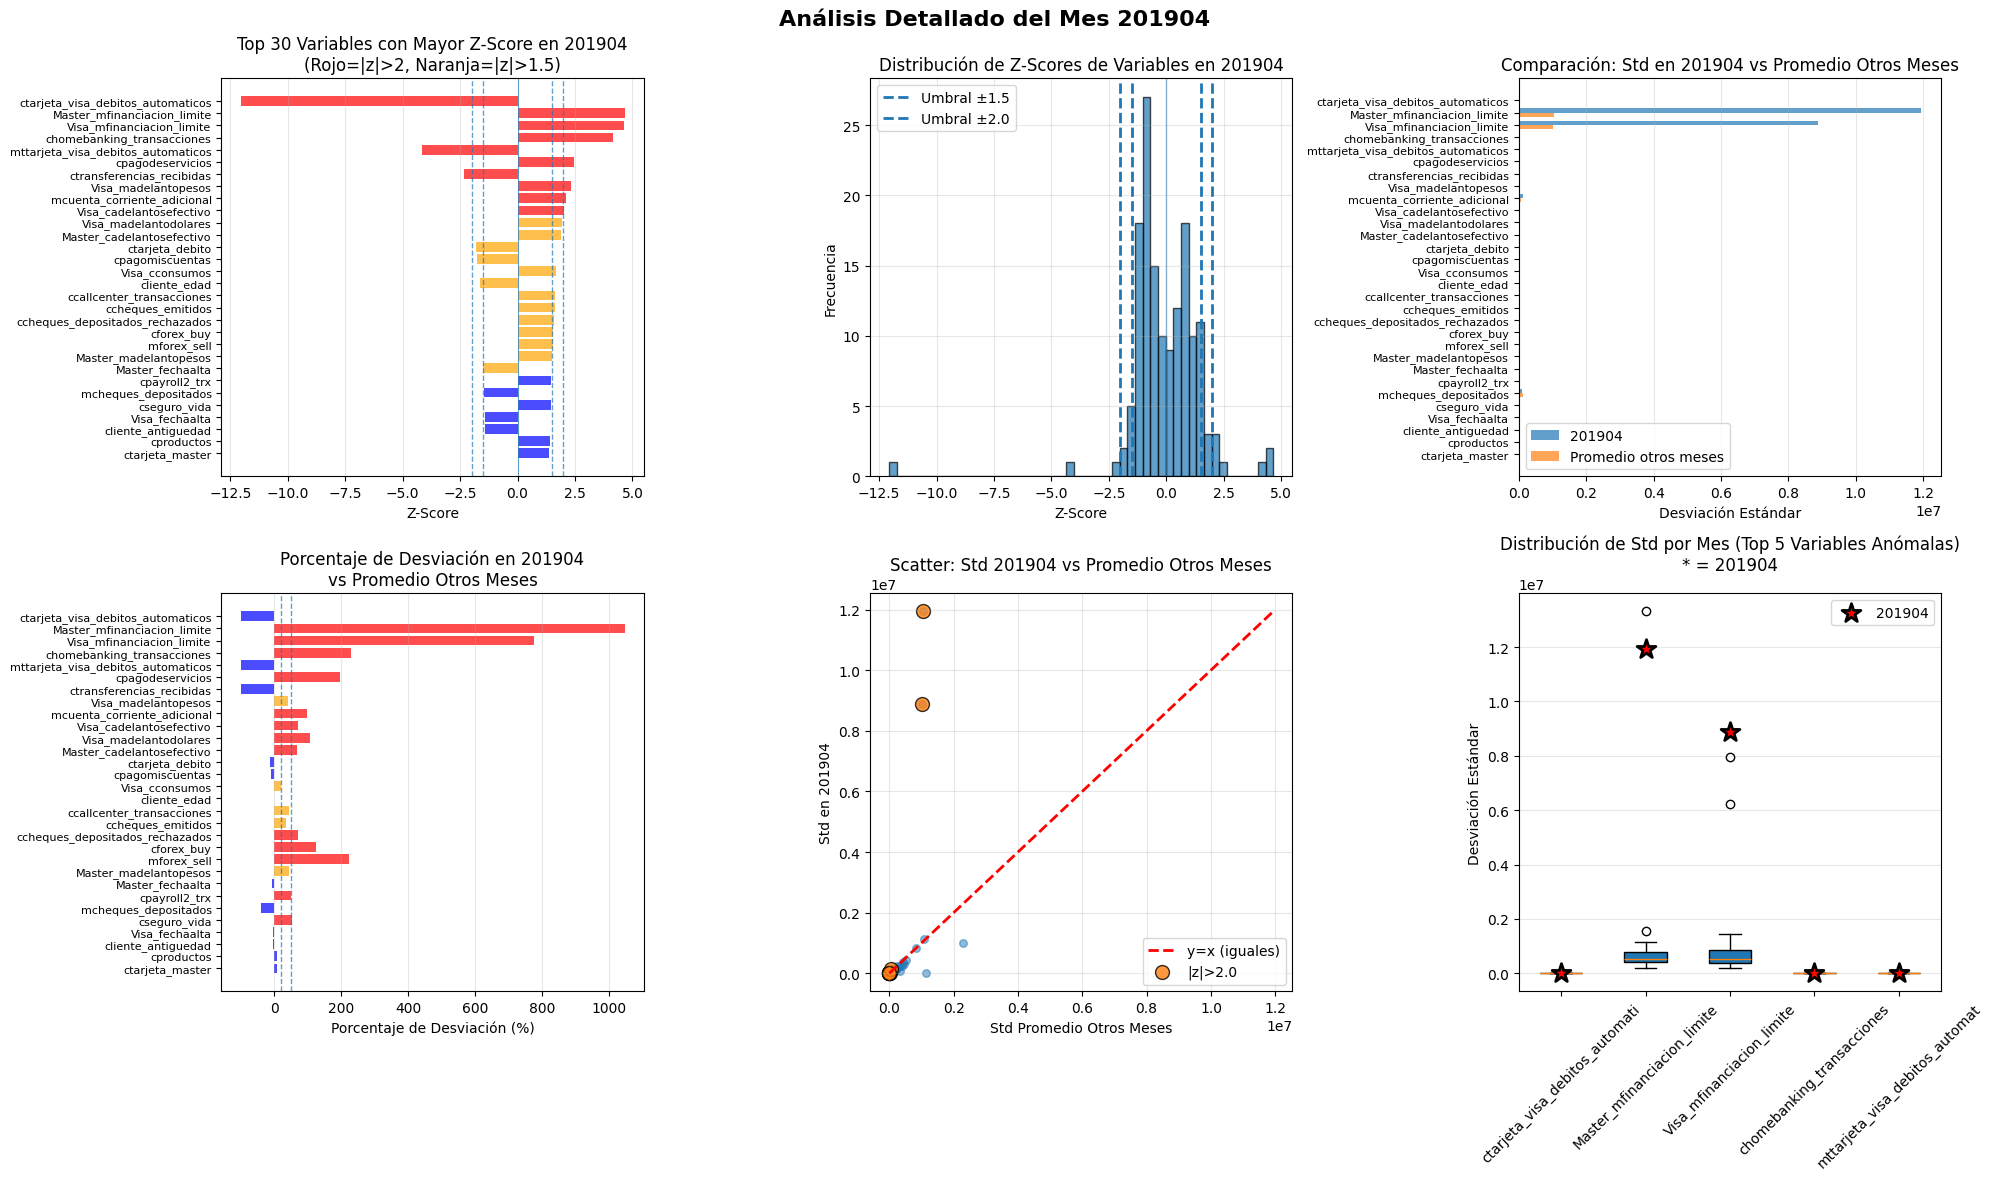


RESUMEN FINAL - MES 201904

✅ Total de variables analizadas: 152
⚠️  Variables con |z-score| > 2.0: 10 (6.6%)
📈 Variables con |z-score| > 1.5: 23 (15.1%)

💡 El mes 201904 tiene alta variabilidad principalmente en:
   - Visa: z-score promedio = 1.58

ANÁLISIS DEL MES 202006

📊 RESUMEN DEL MES 202006
   - Desviación estándar promedio: 53796.5699
   - Desviación estándar promedio de otros meses: 81754.1532
   - Diferencia: -27957.5833

TOP 20 VARIABLES CON MAYOR Z-SCORE (más anómalas en 202006)
                     variable  std_mes_202006  std_promedio_otros_meses  porcentaje_desviacion    z_score
                 thomebanking        0.000000              4.282547e-01            -100.000000 -30.555908
               active_quarter        0.000000              1.172453e-01            -100.000000 -16.057708
                     catm_trx        0.000000              3.733490e+00            -100.000000 -15.215444
     cextraccion_autoservicio        0.000000              4.447105e+00       

<timed exec>:295: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


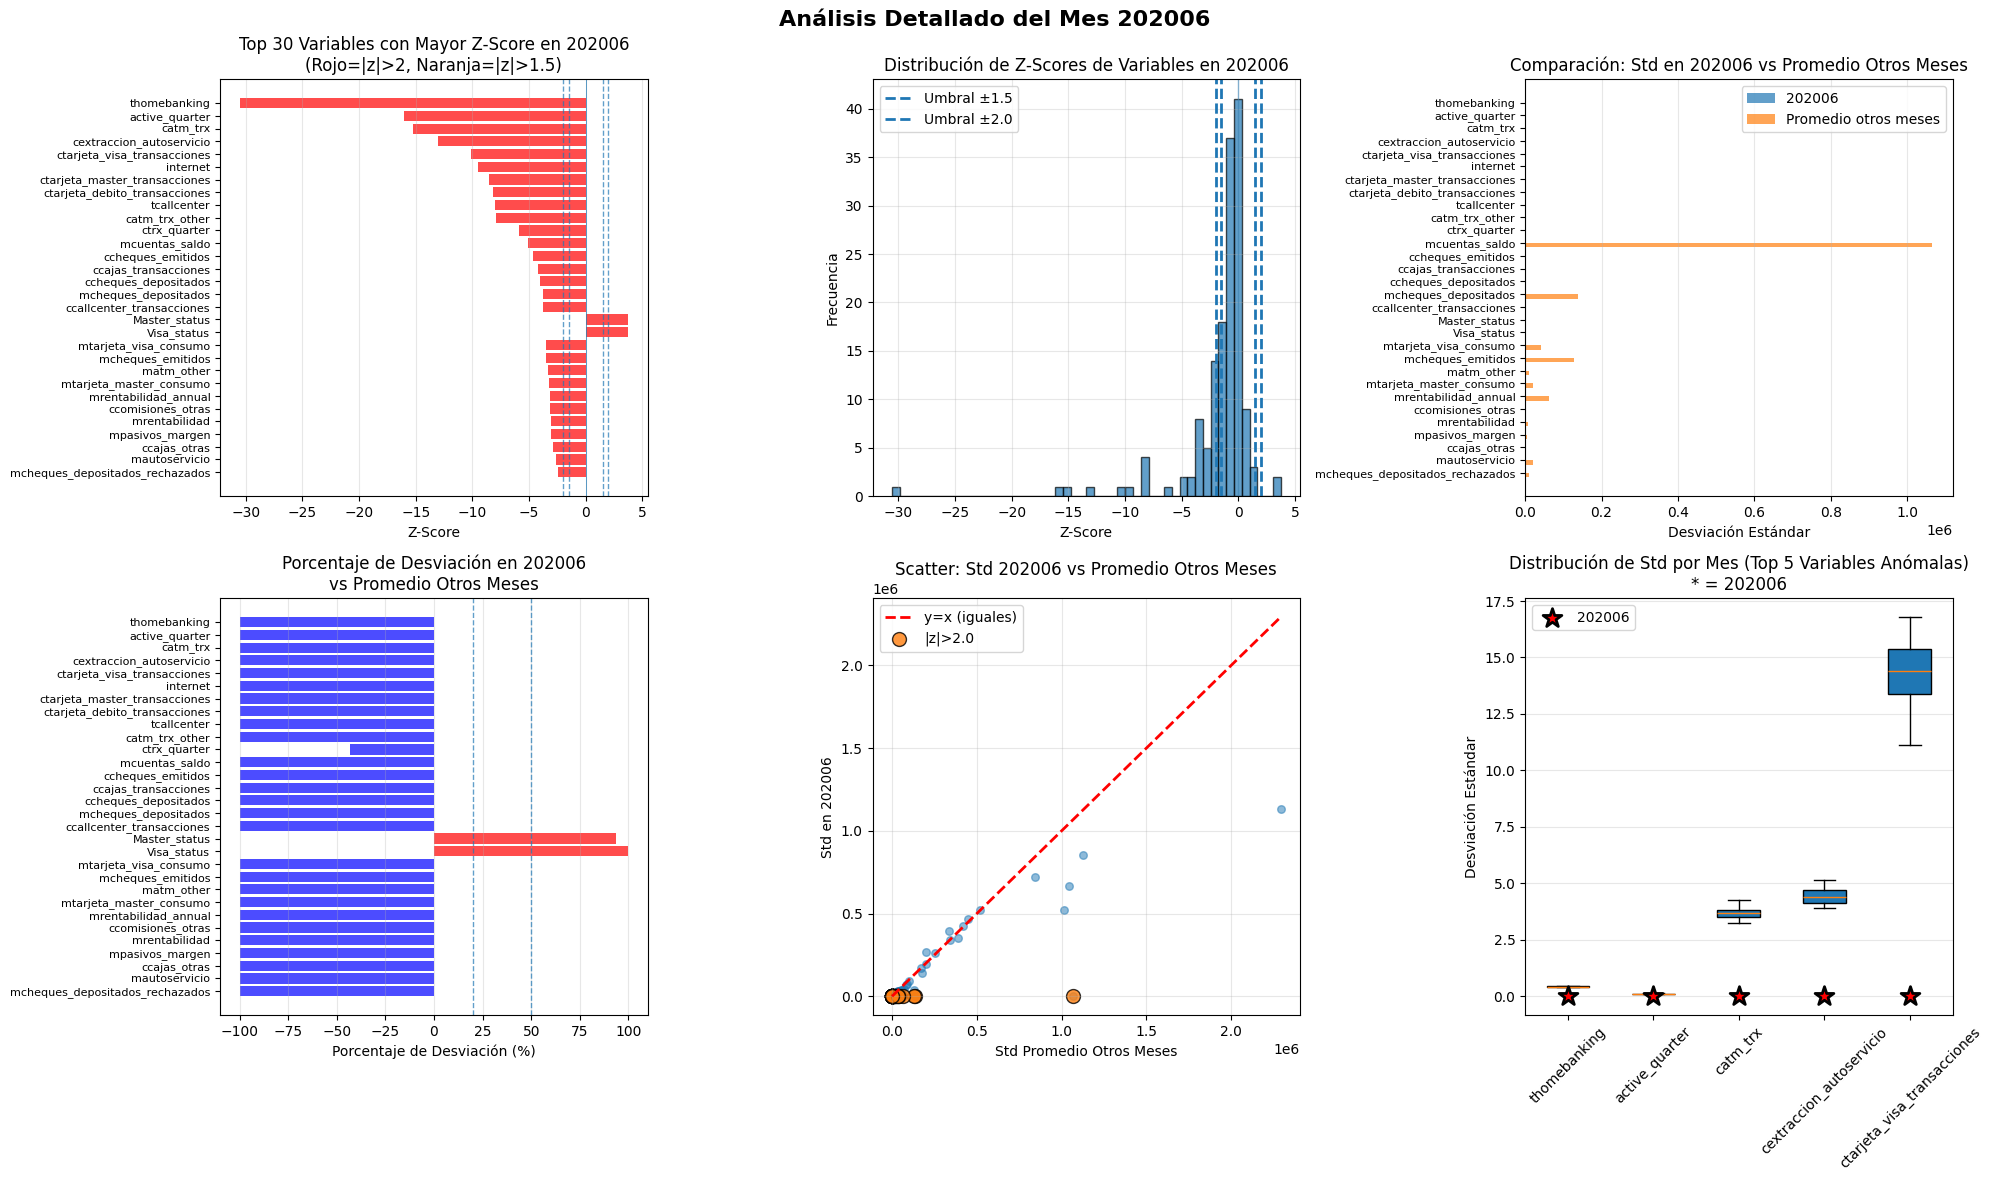


RESUMEN FINAL - MES 202006

✅ Total de variables analizadas: 152
⚠️  Variables con |z-score| > 2.0: 40 (26.3%)
📈 Variables con |z-score| > 1.5: 47 (30.9%)

💡 El mes 202006 tiene alta variabilidad principalmente en:
   - Contadores (c_): z-score promedio = 2.20

ANÁLISIS DEL MES 202010

📊 RESUMEN DEL MES 202010
   - Desviación estándar promedio: 67657.3482
   - Desviación estándar promedio de otros meses: 81754.1532
   - Diferencia: -14096.8050

TOP 20 VARIABLES CON MAYOR Z-SCORE (más anómalas en 202010)
                           variable  std_mes_202010  std_promedio_otros_meses  porcentaje_desviacion   z_score
    mcheques_depositados_rechazados    23430.467493              10174.727197             130.281039  3.213076
        mcuenta_debitos_automaticos   119804.432897              35088.056663             241.439351  2.490352
                 Master_Finiciomora        4.663078                 21.010887             -77.806374 -2.368723
                   Visa_Finiciomora        4.4

<timed exec>:295: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


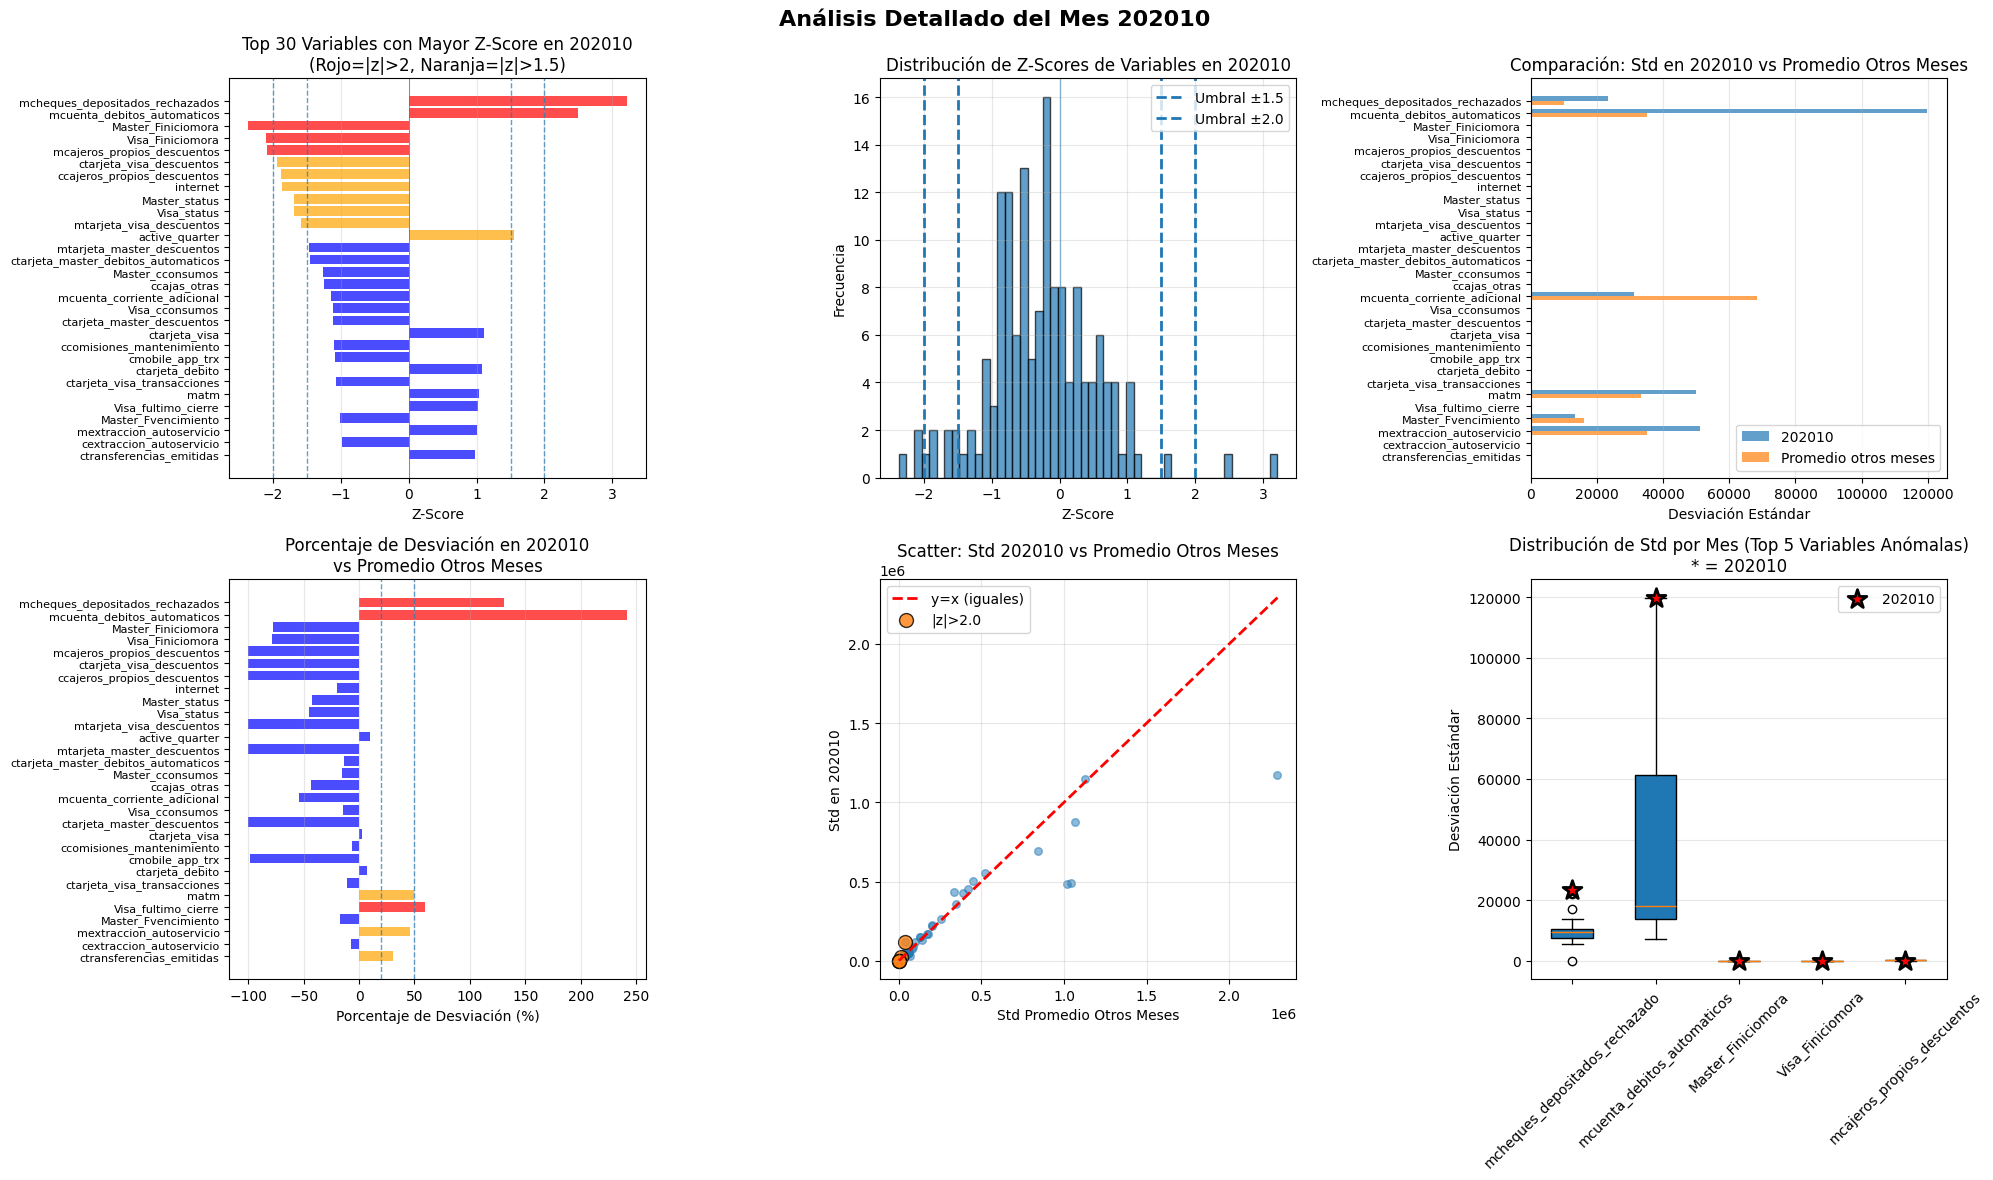


RESUMEN FINAL - MES 202010

✅ Total de variables analizadas: 152
⚠️  Variables con |z-score| > 2.0: 5 (3.3%)
📈 Variables con |z-score| > 1.5: 12 (7.9%)

💡 El mes 202010 tiene alta variabilidad principalmente en:

COMPARACIÓN ENTRE MESES ANÓMALOS

Comparación de métricas entre meses anómalos:
   mes  std_promedio  vars_z_gt_2  vars_z_gt_1_5  z_score_promedio  z_score_maximo
201904 183123.443327           10             23          1.071336       12.055644
202006  53796.569878           40             47          1.929901       30.555908
202010  67657.348190            5             12          0.653261        3.213076

VARIABLES COMUNES ANÓMALAS ENTRE MESES

⚠️  No hay variables anómalas comunes a todos los meses.

📊 Variables anómalas (|z|>1.5) en AL MENOS 2 meses: 13
Variables compartidas:
   - Master_status
   - Visa_status
   - active_quarter
   - ccajeros_propios_descuentos
   - ccallcenter_transacciones
   - ccheques_depositados_rechazados
   - ccheques_emitidos
   - chomebanking

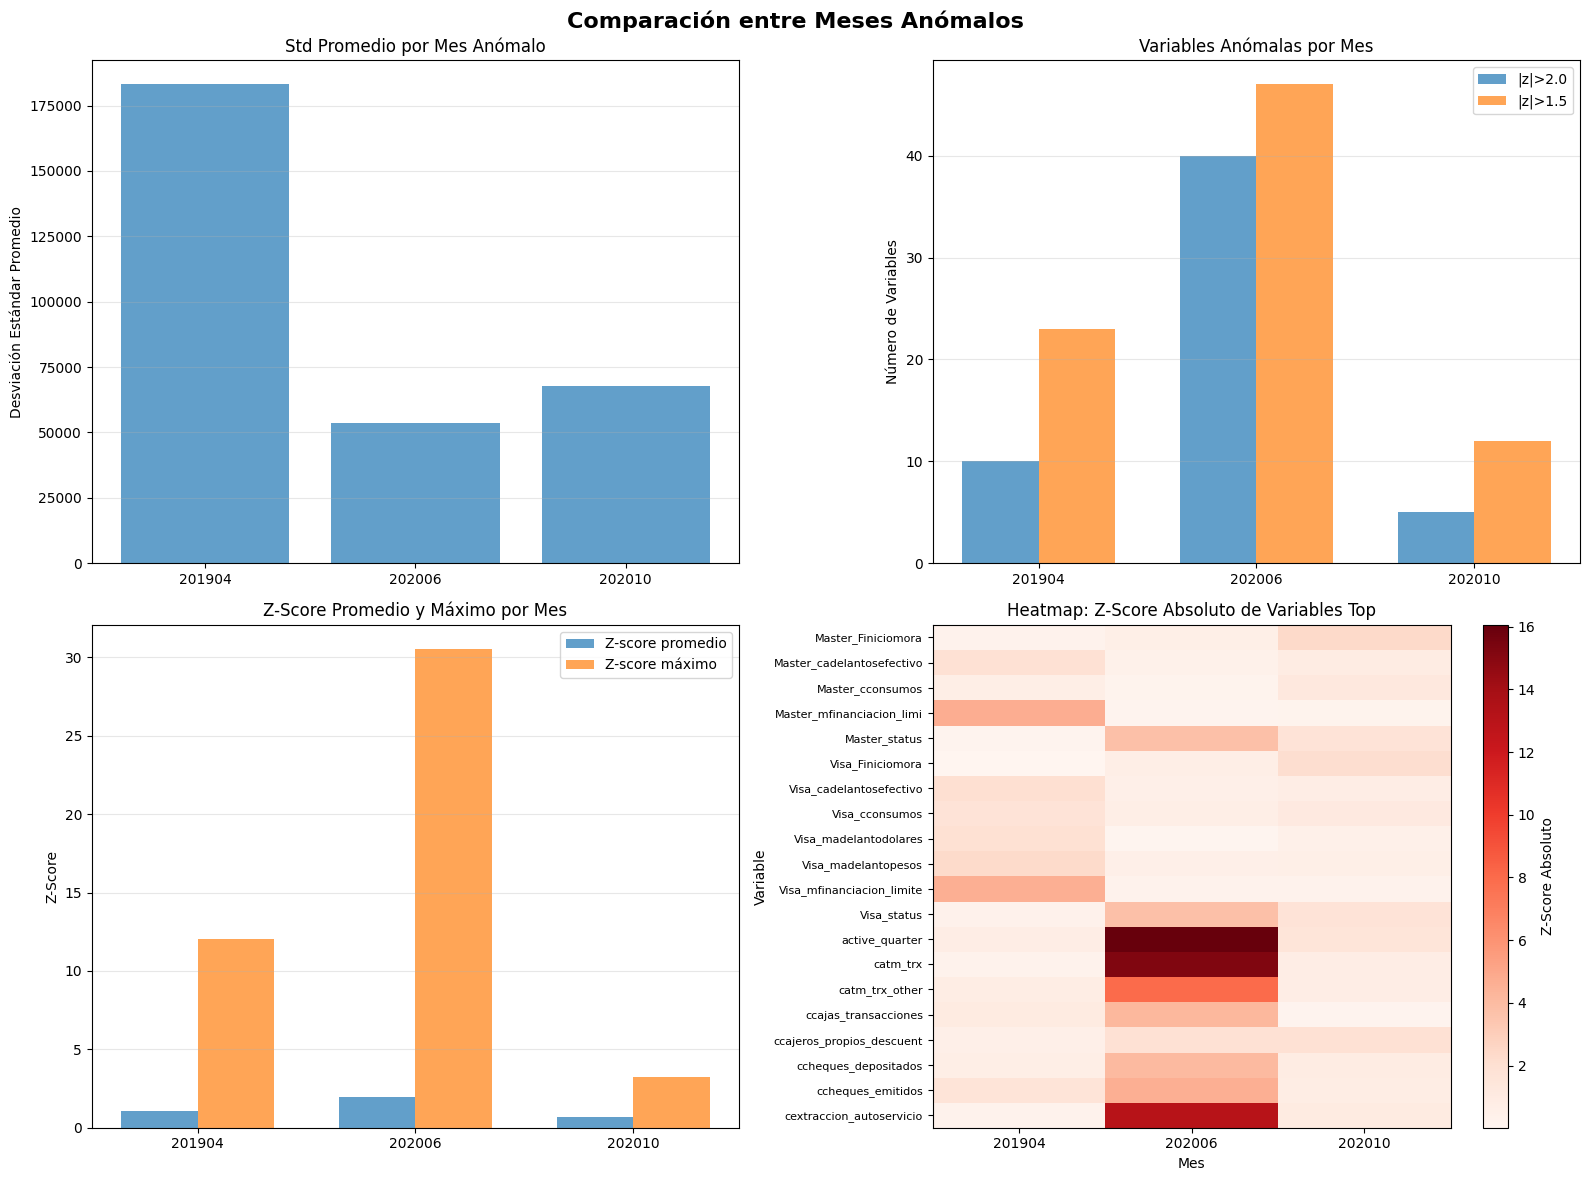


CPU times: user 23.6 s, sys: 157 ms, total: 23.8 s
Wall time: 7.58 s


In [9]:
%%time
# =========================
# 3.1.1) Análisis detallado de meses anómalos - ¿Qué causa la alta variabilidad?
# =========================

meses_analizar = [201904, 202006, 202010]

print("=" * 80)
print(f"ANÁLISIS DETALLADO DE MESES: {meses_analizar}")
print("=" * 80)

# Excluir columnas no numéricas o de metadata
EXCLUDE_ANOMALY = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Obtener columnas numéricas (sin lags aún)
num_cols_base = [
    c for c, dt in zip(df.columns, df.dtypes)
    if c not in EXCLUDE_ANOMALY and dt.is_numeric()
]

# Calcular desviación estándar por mes para cada variable
std_por_mes_detalle = (
    df.lazy()
      .group_by("foto_mes")
      .agg([
          *[pl.col(c).std().alias(f"{c}_std") for c in num_cols_base]
      ])
      .sort("foto_mes")
      .collect()
)

# Convertir a pandas
std_df_detalle = std_por_mes_detalle.to_pandas()
meses_detalle = std_df_detalle["foto_mes"].values

# Verificar que todos los meses estén en el dataset
meses_validos = [m for m in meses_analizar if m in meses_detalle]
meses_no_validos = [m for m in meses_analizar if m not in meses_detalle]

if meses_no_validos:
    print(f"\n⚠️  Meses no encontrados en el dataset: {meses_no_validos}")

if not meses_validos:
    print(f"\n❌ Ninguno de los meses solicitados está en el dataset.")
else:
    # Almacenar resultados de todos los meses
    resultados_todos_meses = {}

    # Calcular stats globales excluyendo los meses anómalos (sirve para todos los meses)
    meses_normales = [m for m in meses_detalle if m not in meses_validos]
    std_df_normales = std_df_detalle[std_df_detalle["foto_mes"].isin(meses_normales)]

    std_media_por_variable = std_df_normales.drop(columns=["foto_mes"]).mean()
    std_std_por_variable = std_df_normales.drop(columns=["foto_mes"]).std()

    for mes_analizar in meses_validos:
        print("\n" + "=" * 80)
        print(f"ANÁLISIS DEL MES {mes_analizar}")
        print("=" * 80)

        # Filtrar datos del mes a analizar
        std_mes_analizar = std_df_detalle[std_df_detalle["foto_mes"] == mes_analizar].iloc[0]

        # Crear DataFrame con análisis detallado
        analisis_detalle = []
        for col in num_cols_base:
            col_std = f"{col}_std"

            std_val_mes = std_mes_analizar[col_std]
            std_media_global = std_media_por_variable[col_std]
            std_std_global = std_std_por_variable[col_std]

            if std_std_global > 0:
                z_score_var = (std_val_mes - std_media_global) / std_std_global
                desviacion_abs = std_val_mes - std_media_global
                porcentaje_desviacion = (desviacion_abs / (std_media_global + 1e-10)) * 100
            else:
                z_score_var = 0
                desviacion_abs = std_val_mes - std_media_global
                porcentaje_desviacion = 0

            analisis_detalle.append({
                "variable": col,
                f"std_mes_{mes_analizar}": std_val_mes,
                "std_promedio_otros_meses": std_media_global,
                "desviacion_absoluta": desviacion_abs,
                "porcentaje_desviacion": porcentaje_desviacion,
                "z_score": z_score_var
            })

        df_analisis = pd.DataFrame(analisis_detalle)

        # Ordenar por z-score absoluto (las más anómalas primero)
        df_analisis["z_score_abs"] = df_analisis["z_score"].abs()
        df_analisis = df_analisis.sort_values("z_score_abs", ascending=False)

        # Guardar resultados
        resultados_todos_meses[mes_analizar] = {
            "df_analisis": df_analisis,
            "std_mes_analizar": std_mes_analizar
        }

        col_std_mes = f"std_mes_{mes_analizar}"

        print(f"\n📊 RESUMEN DEL MES {mes_analizar}")
        print(f"   - Desviación estándar promedio: {df_analisis[col_std_mes].mean():.4f}")
        print(f"   - Desviación estándar promedio de otros meses: {df_analisis['std_promedio_otros_meses'].mean():.4f}")
        print(f"   - Diferencia: {df_analisis[col_std_mes].mean() - df_analisis['std_promedio_otros_meses'].mean():.4f}")

        # Top 20 variables más problemáticas
        print("\n" + "=" * 80)
        print(f"TOP 20 VARIABLES CON MAYOR Z-SCORE (más anómalas en {mes_analizar})")
        print("=" * 80)
        top_20 = df_analisis.head(20)
        print(
            top_20[[
                "variable", col_std_mes, "std_promedio_otros_meses",
                "porcentaje_desviacion", "z_score"
            ]].to_string(index=False)
        )

        # Variables con z-score > 2 (muy anómalas)
        vars_muy_anomalas = df_analisis[df_analisis["z_score_abs"] > 2.0]
        print(f"\n⚠️  Variables con |z-score| > 2.0: {len(vars_muy_anomalas)}")
        if len(vars_muy_anomalas) > 0:
            print("\nVariables muy anómalas:")
            for _, row in vars_muy_anomalas.head(10).iterrows():
                print(
                    f"   - {row['variable']}: z-score={row['z_score']:.2f}, "
                    f"desviación={row['porcentaje_desviacion']:.1f}%"
                )

        # Variables con z-score > 1.5 (anómalas)
        vars_anomalas = df_analisis[df_analisis["z_score_abs"] > 1.5]
        print(f"\n📈 Variables con |z-score| > 1.5: {len(vars_anomalas)}")

        # Estadísticas por categoría de variables
        print("\n" + "=" * 80)
        print("ANÁLISIS POR CATEGORÍAS DE VARIABLES")
        print("=" * 80)

        categorias = {
            "Montos (m_)": [c for c in num_cols_base if c.startswith("m_")],
            "Contadores (c_)": [c for c in num_cols_base if c.startswith("c") and not c.startswith("m_")],
            "Visa": [c for c in num_cols_base if "Visa" in c or "visa" in c],
            "Master": [c for c in num_cols_base if "Master" in c or "master" in c],
            "Payroll": [c for c in num_cols_base if "payroll" in c.lower()],
            "Prestamos": [c for c in num_cols_base if "prestamo" in c.lower()],
            "Inversiones": [c for c in num_cols_base if "inversion" in c.lower() or "plazo_fijo" in c.lower()],
        }

        for cat_name, vars_cat in categorias.items():
            if len(vars_cat) > 0:
                df_cat = df_analisis[df_analisis["variable"].isin(vars_cat)]
                if len(df_cat) > 0:
                    z_score_promedio = df_cat["z_score_abs"].mean()
                    vars_anomalas_cat = len(df_cat[df_cat["z_score_abs"] > 1.5])

                    print(f"\n{cat_name}:")
                    print(f"   - Variables en categoría: {len(df_cat)}")
                    print(f"   - Z-score promedio (abs): {z_score_promedio:.2f}")
                    print(f"   - Variables anómalas (|z|>1.5): {vars_anomalas_cat}")

                    if vars_anomalas_cat > 0:
                        top_cat = df_cat.nlargest(3, "z_score_abs")
                        print(f"   - Top 3 más anómalas:")
                        for _, row in top_cat.iterrows():
                            print(f"     * {row['variable']}: z={row['z_score']:.2f}")

        # Visualizaciones individuales por mes
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle(f"Análisis Detallado del Mes {mes_analizar}",
                     fontsize=16, fontweight='bold')

        # 1. Top 30 variables con mayor z-score
        ax1 = axes[0, 0]
        top_30 = df_analisis.head(30)
        colors = [
            'red' if abs(z) > 2 else 'orange' if abs(z) > 1.5 else 'blue'
            for z in top_30["z_score"]
        ]
        ax1.barh(range(len(top_30)), top_30["z_score"].values,
                 color=colors, alpha=0.7)
        ax1.set_yticks(range(len(top_30)))
        ax1.set_yticklabels(top_30["variable"].values, fontsize=8)
        ax1.set_xlabel("Z-Score")
        ax1.set_title(
            f"Top 30 Variables con Mayor Z-Score en {mes_analizar}\n"
            "(Rojo=|z|>2, Naranja=|z|>1.5)"
        )
        ax1.axvline(1.5, linestyle='--', linewidth=1, alpha=0.7)
        ax1.axvline(-1.5, linestyle='--', linewidth=1, alpha=0.7)
        ax1.axvline(2.0, linestyle='--', linewidth=1, alpha=0.7)
        ax1.axvline(-2.0, linestyle='--', linewidth=1, alpha=0.7)
        ax1.axvline(0, linestyle='-', linewidth=0.5)
        ax1.invert_yaxis()
        ax1.grid(axis='x', alpha=0.3)

        # 2. Distribución de z-scores
        ax2 = axes[0, 1]
        ax2.hist(df_analisis["z_score"], bins=50, edgecolor='black',
                 alpha=0.7)
        ax2.axvline(1.5, linestyle='--', linewidth=2, label='Umbral ±1.5')
        ax2.axvline(-1.5, linestyle='--', linewidth=2)
        ax2.axvline(2.0, linestyle='--', linewidth=2, label='Umbral ±2.0')
        ax2.axvline(-2.0, linestyle='--', linewidth=2)
        ax2.axvline(0, linestyle='-', linewidth=1, alpha=0.5)
        ax2.set_xlabel("Z-Score")
        ax2.set_ylabel("Frecuencia")
        ax2.set_title(f"Distribución de Z-Scores de Variables en {mes_analizar}")
        ax2.legend()
        ax2.grid(alpha=0.3)

        # 3. Comparación: std en mes_analizar vs promedio otros meses (top 30)
        ax3 = axes[0, 2]
        top_30_comp = df_analisis.head(30)
        x_pos = np.arange(len(top_30_comp))
        width = 0.35

        ax3.barh(
            x_pos - width / 2, top_30_comp[col_std_mes].values, width,
            label=f'{mes_analizar}', alpha=0.7
        )
        ax3.barh(
            x_pos + width / 2, top_30_comp["std_promedio_otros_meses"].values,
            width, label='Promedio otros meses', alpha=0.7
        )
        ax3.set_yticks(x_pos)
        ax3.set_yticklabels(top_30_comp["variable"].values, fontsize=8)
        ax3.set_xlabel("Desviación Estándar")
        ax3.set_title(f"Comparación: Std en {mes_analizar} vs Promedio Otros Meses")
        ax3.legend()
        ax3.invert_yaxis()
        ax3.grid(axis='x', alpha=0.3)

        # 4. Porcentaje de desviación (top 30)
        ax4 = axes[1, 0]
        top_30_pct = df_analisis.head(30)
        colors_pct = [
            'red' if p > 50 else 'orange' if p > 20 else 'blue'
            for p in top_30_pct["porcentaje_desviacion"]
        ]
        ax4.barh(
            range(len(top_30_pct)), top_30_pct["porcentaje_desviacion"].values,
            color=colors_pct, alpha=0.7
        )
        ax4.set_yticks(range(len(top_30_pct)))
        ax4.set_yticklabels(top_30_pct["variable"].values, fontsize=8)
        ax4.set_xlabel("Porcentaje de Desviación (%)")
        ax4.set_title(
            f"Porcentaje de Desviación en {mes_analizar}\nvs Promedio Otros Meses"
        )
        ax4.axvline(20, linestyle='--', linewidth=1, alpha=0.7)
        ax4.axvline(50, linestyle='--', linewidth=1, alpha=0.7)
        ax4.invert_yaxis()
        ax4.grid(axis='x', alpha=0.3)

        # 5. Scatter: std mes_analizar vs std promedio otros meses
        ax5 = axes[1, 1]
        ax5.scatter(
            df_analisis["std_promedio_otros_meses"],
            df_analisis[col_std_mes],
            alpha=0.5, s=30
        )
        max_val = max(
            df_analisis["std_promedio_otros_meses"].max(),
            df_analisis[col_std_mes].max()
        )
        ax5.plot([0, max_val], [0, max_val], 'r--', linewidth=2,
                 label='y=x (iguales)')
        vars_extremas = df_analisis[df_analisis["z_score_abs"] > 2.0]
        if len(vars_extremas) > 0:
            ax5.scatter(
                vars_extremas["std_promedio_otros_meses"],
                vars_extremas[col_std_mes],
                s=100, alpha=0.8, label='|z|>2.0',
                edgecolors='black'
            )
        ax5.set_xlabel("Std Promedio Otros Meses")
        ax5.set_ylabel(f"Std en {mes_analizar}")
        ax5.set_title(f"Scatter: Std {mes_analizar} vs Promedio Otros Meses")
        ax5.legend()
        ax5.grid(alpha=0.3)

        # 6. Boxplot de desviaciones estándar por mes (solo algunas variables clave)
        ax6 = axes[1, 2]
        top_5_vars = df_analisis.head(5)["variable"].tolist()

        data_boxplot, labels_boxplot = [], []
        for var in top_5_vars:
            col_std = f"{var}_std"
            valores = std_df_detalle[col_std].values
            data_boxplot.append(valores)
            labels_boxplot.append(var[:30])

        ax6.boxplot(
            data_boxplot, labels=labels_boxplot,
            vert=True, patch_artist=True
        )

        for i, var in enumerate(top_5_vars):
            col_std = f"{var}_std"
            std_val_mes = std_mes_analizar[col_std]
            ax6.scatter(
                [i + 1], [std_val_mes], s=200, c='red', marker='*',
                zorder=10, edgecolors='black', linewidth=2,
                label=f'{mes_analizar}' if i == 0 else ''
            )

        ax6.set_ylabel("Desviación Estándar")
        ax6.set_title(
            f"Distribución de Std por Mes (Top 5 Variables Anómalas)\n"
            f"* = {mes_analizar}"
        )
        ax6.tick_params(axis='x', rotation=45)
        ax6.grid(axis='y', alpha=0.3)
        ax6.legend()

        plt.tight_layout()
        plt.show()

        # Resumen final por mes
        print("\n" + "=" * 80)
        print(f"RESUMEN FINAL - MES {mes_analizar}")
        print("=" * 80)

        print(f"\n✅ Total de variables analizadas: {len(df_analisis)}")
        print(f"⚠️  Variables con |z-score| > 2.0: {len(vars_muy_anomalas)} "
              f"({len(vars_muy_anomalas)/len(df_analisis)*100:.1f}%)")
        print(f"📈 Variables con |z-score| > 1.5: {len(vars_anomalas)} "
              f"({len(vars_anomalas)/len(df_analisis)*100:.1f}%)")

        print(f"\n💡 El mes {mes_analizar} tiene alta variabilidad principalmente en:")
        if len(vars_muy_anomalas) > 0:
            top_categorias = []
            for cat_name, vars_cat in categorias.items():
                df_cat = df_analisis[df_analisis["variable"].isin(vars_cat)]
                if len(df_cat) > 0:
                    z_prom = df_cat["z_score_abs"].mean()
                    if z_prom > 1.5:
                        top_categorias.append((cat_name, z_prom))

            top_categorias.sort(key=lambda x: x[1], reverse=True)
            for cat, z_prom in top_categorias[:5]:
                print(f"   - {cat}: z-score promedio = {z_prom:.2f}")

    # Comparación entre meses anómalos
    if len(resultados_todos_meses) > 1:
        print("\n" + "=" * 80)
        print("COMPARACIÓN ENTRE MESES ANÓMALOS")
        print("=" * 80)

        comparacion_meses = []
        for mes, resultados in resultados_todos_meses.items():
            df_mes = resultados["df_analisis"]
            comparacion_meses.append({
                "mes": mes,
                "std_promedio": df_mes[f"std_mes_{mes}"].mean(),
                "vars_z_gt_2": len(df_mes[df_mes["z_score_abs"] > 2.0]),
                "vars_z_gt_1_5": len(df_mes[df_mes["z_score_abs"] > 1.5]),
                "z_score_promedio": df_mes["z_score_abs"].mean(),
                "z_score_maximo": df_mes["z_score_abs"].max()
            })

        df_comparacion = pd.DataFrame(comparacion_meses)
        print("\nComparación de métricas entre meses anómalos:")
        print(df_comparacion.to_string(index=False))

        print("\n" + "=" * 80)
        print("VARIABLES COMUNES ANÓMALAS ENTRE MESES")
        print("=" * 80)

        vars_por_mes = {}
        for mes, resultados in resultados_todos_meses.items():
            df_mes = resultados["df_analisis"]
            top_vars = df_mes[df_mes["z_score_abs"] > 1.5]["variable"].tolist()
            vars_por_mes[mes] = set(top_vars)

        if len(vars_por_mes) > 1:
            vars_comunes = set.intersection(*vars_por_mes.values())
            if vars_comunes:
                print(f"\n✅ Variables anómalas (|z|>1.5) en TODOS los meses analizados: {len(vars_comunes)}")
                print("Variables comunes:")
                for var in sorted(list(vars_comunes))[:20]:
                    print(f"   - {var}")
            else:
                print("\n⚠️  No hay variables anómalas comunes a todos los meses.")

            vars_en_al_menos_2 = set()
            for mes1, vars1 in vars_por_mes.items():
                for mes2, vars2 in vars_por_mes.items():
                    if mes1 != mes2:
                        vars_en_al_menos_2.update(vars1.intersection(vars2))

            if vars_en_al_menos_2:
                print(f"\n📊 Variables anómalas (|z|>1.5) en AL MENOS 2 meses: {len(vars_en_al_menos_2)}")
                print("Variables compartidas:")
                for var in sorted(list(vars_en_al_menos_2))[:30]:
                    print(f"   - {var}")

        # Visualización comparativa
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle("Comparación entre Meses Anómalos", fontsize=16, fontweight='bold')

        # 1. Comparación de std promedio
        ax1 = axes[0, 0]
        meses_comp = df_comparacion["mes"].tolist()
        stds_comp = df_comparacion["std_promedio"].tolist()
        ax1.bar(range(len(meses_comp)), stds_comp, alpha=0.7)
        ax1.set_xticks(range(len(meses_comp)))
        ax1.set_xticklabels(meses_comp)
        ax1.set_ylabel("Desviación Estándar Promedio")
        ax1.set_title("Std Promedio por Mes Anómalo")
        ax1.grid(axis='y', alpha=0.3)

        # 2. Número de variables anómalas
        ax2 = axes[0, 1]
        x = np.arange(len(meses_comp))
        width = 0.35
        ax2.bar(x - width/2, df_comparacion["vars_z_gt_2"].tolist(), width,
                label='|z|>2.0', alpha=0.7)
        ax2.bar(x + width/2, df_comparacion["vars_z_gt_1_5"].tolist(), width,
                label='|z|>1.5', alpha=0.7)
        ax2.set_xticks(x)
        ax2.set_xticklabels(meses_comp)
        ax2.set_ylabel("Número de Variables")
        ax2.set_title("Variables Anómalas por Mes")
        ax2.legend()
        ax2.grid(axis='y', alpha=0.3)

        # 3. Z-score promedio y máximo
        ax3 = axes[1, 0]
        ax3.bar(x - width/2, df_comparacion["z_score_promedio"].tolist(), width,
                label='Z-score promedio', alpha=0.7)
        ax3.bar(x + width/2, df_comparacion["z_score_maximo"].tolist(), width,
                label='Z-score máximo', alpha=0.7)
        ax3.set_xticks(x)
        ax3.set_xticklabels(meses_comp)
        ax3.set_ylabel("Z-Score")
        ax3.set_title("Z-Score Promedio y Máximo por Mes")
        ax3.legend()
        ax3.grid(axis='y', alpha=0.3)

        # 4. Heatmap de variables más anómalas compartidas
        ax4 = axes[1, 1]
        top_vars_all = set()
        for mes, resultados in resultados_todos_meses.items():
            df_mes = resultados["df_analisis"]
            top_vars_all.update(df_mes.head(15)["variable"].tolist())

        top_vars_all = sorted(list(top_vars_all))[:20]

        matriz_comparacion = []
        for var in top_vars_all:
            fila = []
            for mes in meses_comp:
                df_mes = resultados_todos_meses[mes]["df_analisis"]
                var_data = df_mes[df_mes["variable"] == var]
                fila.append(var_data["z_score_abs"].iloc[0] if len(var_data) > 0 else 0)
            matriz_comparacion.append(fila)

        if matriz_comparacion:
            im = ax4.imshow(matriz_comparacion, aspect='auto', cmap='Reds')
            ax4.set_xticks(range(len(meses_comp)))
            ax4.set_xticklabels(meses_comp)
            ax4.set_yticks(range(len(top_vars_all)))
            ax4.set_yticklabels([v[:25] for v in top_vars_all], fontsize=8)
            ax4.set_xlabel("Mes")
            ax4.set_ylabel("Variable")
            ax4.set_title("Heatmap: Z-Score Absoluto de Variables Top")
            plt.colorbar(im, ax=ax4, label='Z-Score Absoluto')

        plt.tight_layout()
        plt.show()

        print("\n" + "=" * 80)


In [10]:
%%time
# =========================
# ANÁLISIS EXHAUSTIVO DE VARIABLES ROTAS POR MES
# =========================
# 
# Este análisis identifica todas las variables que están "rotas" en diferentes meses
# usando múltiples métricas: Z-score, PSI, desviación de media/mediana, valores en cero,
# valores faltantes, coeficiente de variación, etc.
#
# Objetivo: Identificar variables-mes que necesitan corrección para mejorar predicciones

print("="*80)
print("ANÁLISIS EXHAUSTIVO DE VARIABLES ROTAS POR MES")
print("="*80)

# Excluir columnas no numéricas o de metadata
EXCLUDE_ANOMALY = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Obtener columnas numéricas (sin lags aún, solo variables base)
num_cols_base = [c for c, dt in zip(df.columns, df.dtypes)
                 if c not in EXCLUDE_ANOMALY and dt.is_numeric()]

# Excluir también variables generadas (lags, deltas, percentiles, canaritos)
num_cols_base = [c for c in num_cols_base 
                 if not any(x in c for x in ['_lag', '_d1', '_d2', '_p', '_percentile', '_above', 'canarito'])]

print(f"\n📊 Analizando {len(num_cols_base)} variables numéricas base")
print(f"📅 Meses disponibles: {sorted(df['foto_mes'].unique().to_list())}")

# Convertir a pandas para cálculos más complejos
df_pd = df.select(["foto_mes"] + num_cols_base).to_pandas()
meses = sorted(df_pd["foto_mes"].unique())

# Función para calcular PSI (ya definida antes, pero la incluimos aquí por si acaso)
def calculate_psi(expected, actual, bins=10):
    """Calcula el Population Stability Index (PSI) entre dos distribuciones."""
    expected = expected[~np.isnan(expected)]
    actual = actual[~np.isnan(actual)]
    
    if len(expected) == 0 or len(actual) == 0:
        return np.nan
    
    min_val = min(expected.min(), actual.min())
    max_val = max(expected.max(), actual.max())
    
    if max_val == min_val:
        return 0.0
    
    bin_edges = np.linspace(min_val, max_val, bins + 1)
    expected_counts, _ = np.histogram(expected, bins=bin_edges)
    actual_counts, _ = np.histogram(actual, bins=bin_edges)
    
    expected_prop = expected_counts / (len(expected) + 1e-10)
    actual_prop = actual_counts / (len(actual) + 1e-10)
    
    expected_prop = np.where(expected_prop == 0, 1e-10, expected_prop)
    actual_prop = np.where(actual_prop == 0, 1e-10, actual_prop)
    
    psi = np.sum((actual_prop - expected_prop) * np.log(actual_prop / expected_prop))
    return psi

# Calcular estadísticas globales (excluyendo el mes actual para cada comparación)
print("\n🔄 Calculando estadísticas globales por variable...")

# Estadísticas globales por variable (promedio de todos los meses)
stats_globales = {}
for col in num_cols_base:
    valores_globales = df_pd[col].dropna()
    if len(valores_globales) > 0:
        stats_globales[col] = {
            'media': valores_globales.mean(),
            'mediana': valores_globales.median(),
            'std': valores_globales.std(),
            'q25': valores_globales.quantile(0.25),
            'q75': valores_globales.quantile(0.75),
            'pct_ceros': (valores_globales == 0).sum() / len(valores_globales) * 100,
            'pct_nulos': df_pd[col].isna().sum() / len(df_pd) * 100,
        }
    else:
        stats_globales[col] = {
            'media': 0, 'mediana': 0, 'std': 0, 'q25': 0, 'q75': 0,
            'pct_ceros': 0, 'pct_nulos': 100
        }

# Calcular estadísticas por mes para cada variable
print("🔄 Calculando métricas por variable y mes...")

resultados_detallados = []

for mes in meses:
    df_mes = df_pd[df_pd["foto_mes"] == mes]
    df_otros_meses = df_pd[df_pd["foto_mes"] != mes]
    
    for col in num_cols_base:
        valores_mes = df_mes[col].dropna()
        valores_otros = df_otros_meses[col].dropna()
        
        if len(valores_mes) == 0:
            continue
        
        # Estadísticas del mes actual
        media_mes = valores_mes.mean()
        mediana_mes = valores_mes.median()
        std_mes = valores_mes.std()
        pct_ceros_mes = (valores_mes == 0).sum() / len(valores_mes) * 100
        pct_nulos_mes = df_mes[col].isna().sum() / len(df_mes) * 100
        
        # Estadísticas de otros meses
        if len(valores_otros) > 0:
            media_otros = valores_otros.mean()
            mediana_otros = valores_otros.median()
            std_otros = valores_otros.std()
            pct_ceros_otros = (valores_otros == 0).sum() / len(valores_otros) * 100
            
            # Métricas de desviación
            # 1. Z-score de la media
            if std_otros > 0:
                z_score_media = (media_mes - media_otros) / std_otros
            else:
                z_score_media = 0 if media_mes == media_otros else np.inf
            
            # 2. Z-score de la desviación estándar
            std_de_stds = df_otros_meses.groupby("foto_mes")[col].std().std()
            std_promedio = df_otros_meses.groupby("foto_mes")[col].std().mean()
            if std_de_stds > 0:
                z_score_std = (std_mes - std_promedio) / std_de_stds
            else:
                z_score_std = 0
            
            # 3. Desviación porcentual de la media
            if abs(media_otros) > 1e-10:
                pct_desviacion_media = abs((media_mes - media_otros) / media_otros) * 100
            else:
                pct_desviacion_media = 100 if abs(media_mes) > 1e-10 else 0
            
            # 4. Desviación porcentual de la mediana
            if abs(mediana_otros) > 1e-10:
                pct_desviacion_mediana = abs((mediana_mes - mediana_otros) / mediana_otros) * 100
            else:
                pct_desviacion_mediana = 100 if abs(mediana_mes) > 1e-10 else 0
            
            # 5. PSI (Population Stability Index)
            try:
                psi_val = calculate_psi(valores_otros.values, valores_mes.values, bins=10)
                if np.isnan(psi_val) or np.isinf(psi_val):
                    psi_val = 0
            except:
                psi_val = 0
            
            # 6. Coeficiente de variación
            cv_mes = (std_mes / (abs(media_mes) + 1e-10)) * 100
            cv_otros = (std_otros / (abs(media_otros) + 1e-10)) * 100
            desviacion_cv = abs(cv_mes - cv_otros)
            
            # 7. Diferencia en porcentaje de ceros
            diff_pct_ceros = abs(pct_ceros_mes - pct_ceros_otros)
            
        else:
            # Si no hay otros meses, usar estadísticas globales
            stats_glob = stats_globales[col]
            media_otros = stats_glob['media']
            mediana_otros = stats_glob['mediana']
            std_otros = stats_glob['std']
            pct_ceros_otros = stats_glob['pct_ceros']
            
            if std_otros > 0:
                z_score_media = (media_mes - media_otros) / std_otros
            else:
                z_score_media = 0
            
            z_score_std = 0
            if abs(media_otros) > 1e-10:
                pct_desviacion_media = abs((media_mes - media_otros) / media_otros) * 100
            else:
                pct_desviacion_media = 100 if abs(media_mes) > 1e-10 else 0
            
            if abs(mediana_otros) > 1e-10:
                pct_desviacion_mediana = abs((mediana_mes - mediana_otros) / mediana_otros) * 100
            else:
                pct_desviacion_mediana = 100 if abs(mediana_mes) > 1e-10 else 0
            
            psi_val = 0
            cv_mes = (std_mes / (abs(media_mes) + 1e-10)) * 100
            cv_otros = (std_otros / (abs(media_otros) + 1e-10)) * 100
            desviacion_cv = abs(cv_mes - cv_otros)
            diff_pct_ceros = abs(pct_ceros_mes - pct_ceros_otros)
        
        # Calcular score de "rotura" combinando todas las métricas
        # Normalizar cada métrica y combinarlas
        score_rotura = (
            abs(z_score_media) * 0.20 +      # Z-score de media (peso 20%)
            abs(z_score_std) * 0.20 +        # Z-score de std (peso 20%)
            min(pct_desviacion_media / 100, 1) * 0.15 +  # Desviación media (peso 15%)
            min(psi_val / 1.0, 1) * 0.20 +   # PSI (peso 20%, normalizado a 0-1)
            min(diff_pct_ceros / 50, 1) * 0.10 +  # Diferencia en % ceros (peso 10%)
            min(pct_nulos_mes / 50, 1) * 0.10 +   # % nulos (peso 10%)
            min(desviacion_cv / 100, 1) * 0.05    # Desviación CV (peso 5%)
        )
        
        resultados_detallados.append({
            'variable': col,
            'foto_mes': mes,
            'z_score_media': z_score_media,
            'z_score_std': z_score_std,
            'pct_desviacion_media': pct_desviacion_media,
            'pct_desviacion_mediana': pct_desviacion_mediana,
            'psi': psi_val,
            'pct_ceros_mes': pct_ceros_mes,
            'pct_ceros_otros': pct_ceros_otros,
            'diff_pct_ceros': diff_pct_ceros,
            'pct_nulos_mes': pct_nulos_mes,
            'desviacion_cv': desviacion_cv,
            'media_mes': media_mes,
            'media_otros': media_otros,
            'std_mes': std_mes,
            'std_otros': std_otros,
            'score_rotura': score_rotura
        })

# Crear DataFrame con todos los resultados
df_resultados = pd.DataFrame(resultados_detallados)

# Ordenar por score de rotura (mayor a menor)
df_resultados = df_resultados.sort_values('score_rotura', ascending=False)

print(f"\n✅ Análisis completado: {len(df_resultados)} combinaciones variable-mes analizadas")

# Resumen ejecutivo
print("\n" + "="*80)
print("RESUMEN EJECUTIVO: VARIABLES ROTAS POR MES")
print("="*80)
print("\nTop 50 variables-mes con mayor score de rotura:")
print("="*80)

resumen_ejecutivo = df_resultados[['variable', 'foto_mes', 'score_rotura', 
                                    'z_score_media', 'z_score_std', 'psi', 
                                    'pct_desviacion_media', 'pct_ceros_mes', 
                                    'pct_nulos_mes']].head(50)

print(resumen_ejecutivo.to_string(index=False))

# Guardar resumen completo
print("\n" + "="*80)
print("GUARDANDO RESULTADOS COMPLETOS")
print("="*80)

# Guardar todos los resultados
df_resultados.to_csv("analisis_variables_rotas_completo.csv", index=False)
print(f"✅ Resultados completos guardados en: analisis_variables_rotas_completo.csv")

# Guardar resumen ejecutivo (top 100)
df_resultados.head(100)[['variable', 'foto_mes', 'score_rotura', 
                         'z_score_media', 'z_score_std', 'psi', 
                         'pct_desviacion_media', 'pct_ceros_mes', 
                         'pct_nulos_mes', 'diff_pct_ceros']].to_csv(
    "resumen_ejecutivo_variables_rotas.csv", index=False)
print(f"✅ Resumen ejecutivo guardado en: resumen_ejecutivo_variables_rotas.csv")

print("\n" + "="*80)


ANÁLISIS EXHAUSTIVO DE VARIABLES ROTAS POR MES

📊 Analizando 142 variables numéricas base
📅 Meses disponibles: [201901, 201902, 201903, 201904, 201905, 201906, 201907, 201908, 201909, 201910, 201911, 201912, 202001, 202002, 202003, 202004, 202005, 202006, 202007, 202008, 202009, 202010, 202011, 202012, 202101, 202102, 202103, 202104, 202105, 202106, 202107, 202108, 202109]

🔄 Calculando estadísticas globales por variable...
🔄 Calculando métricas por variable y mes...

✅ Análisis completado: 4674 combinaciones variable-mes analizadas

RESUMEN EJECUTIVO: VARIABLES ROTAS POR MES

Top 50 variables-mes con mayor score de rotura:
                          variable  foto_mes  score_rotura  z_score_media  z_score_std       psi  pct_desviacion_media  pct_ceros_mes  pct_nulos_mes
                       minversion2    202109     51.785397       0.162232   257.760773  0.000267            459.568423      96.899323       0.000000
                      thomebanking    202006      7.062011      -1.758

In [11]:
%%time
# =========================
# ANÁLISIS DE VARIABLES CON VALORES EN CERO Y RECOMENDACIONES PARA CONVERSIÓN A NA
# =========================
# 
# Analiza qué variables tienen muchos ceros que deberían ser NA para mejorar
# las predicciones de LightGBM

print("="*80)
print("ANÁLISIS DE VARIABLES CON VALORES EN CERO")
print("="*80)

# Usar las mismas variables base del análisis anterior
# (ya están definidas en la celda anterior, pero las redefinimos por seguridad)
EXCLUDE_ANOMALY = {"numero_de_cliente", "foto_mes", "clase_ternaria"}
num_cols_base = [c for c, dt in zip(df.columns, df.dtypes)
                 if c not in EXCLUDE_ANOMALY and dt.is_numeric()]

num_cols_base = [c for c in num_cols_base 
                 if not any(x in c for x in ['_lag', '_d1', '_d2', '_p', '_percentile', '_above', 'canarito'])]

df_pd = df.select(["foto_mes"] + num_cols_base).to_pandas()

# Analizar porcentaje de ceros por variable y mes
analisis_ceros = []

for col in num_cols_base:
    valores_totales = df_pd[col].dropna()
    
    if len(valores_totales) == 0:
        continue
    
    # Estadísticas globales
    pct_ceros_global = (valores_totales == 0).sum() / len(valores_totales) * 100
    pct_nulos_global = df_pd[col].isna().sum() / len(df_pd) * 100
    
    # Analizar por mes
    pct_ceros_por_mes = []
    for mes in sorted(df_pd["foto_mes"].unique()):
        df_mes = df_pd[df_pd["foto_mes"] == mes]
        valores_mes = df_mes[col].dropna()
        
        if len(valores_mes) > 0:
            pct_ceros = (valores_mes == 0).sum() / len(valores_mes) * 100
            pct_nulos = df_mes[col].isna().sum() / len(df_mes) * 100
            pct_ceros_por_mes.append({
                'mes': mes,
                'pct_ceros': pct_ceros,
                'pct_nulos': pct_nulos
            })
    
    # Calcular variabilidad en % de ceros entre meses
    if len(pct_ceros_por_mes) > 1:
        pcts = [x['pct_ceros'] for x in pct_ceros_por_mes]
        std_pct_ceros = np.std(pcts)
        max_pct_ceros = max(pcts)
        min_pct_ceros = min(pcts)
    else:
        std_pct_ceros = 0
        max_pct_ceros = pct_ceros_global
        min_pct_ceros = pct_ceros_global
    
    # Calcular estadísticas de valores no-cero
    valores_no_cero = valores_totales[valores_totales != 0]
    if len(valores_no_cero) > 0:
        media_no_cero = valores_no_cero.mean()
        mediana_no_cero = valores_no_cero.median()
        std_no_cero = valores_no_cero.std()
    else:
        media_no_cero = 0
        mediana_no_cero = 0
        std_no_cero = 0
    
    # Score de recomendación para convertir ceros a NA
    # Variables con muchos ceros (>80%) y baja variabilidad en valores no-cero
    # son candidatas a convertir ceros a NA
    score_recomendacion = 0
    
    # Factor 1: Alto porcentaje de ceros (>80%)
    if pct_ceros_global > 80:
        score_recomendacion += 0.4
    elif pct_ceros_global > 50:
        score_recomendacion += 0.2
    
    # Factor 2: Alta variabilidad en % de ceros entre meses (indica inconsistencia)
    if std_pct_ceros > 20:
        score_recomendacion += 0.3
    elif std_pct_ceros > 10:
        score_recomendacion += 0.15
    
    # Factor 3: Valores no-cero tienen distribución razonable (no todos iguales)
    if len(valores_no_cero) > 0 and std_no_cero > 0:
        cv_no_cero = (std_no_cero / (abs(media_no_cero) + 1e-10)) * 100
        if cv_no_cero > 50:  # Alta variabilidad en valores no-cero
            score_recomendacion += 0.2
        elif cv_no_cero > 20:
            score_recomendacion += 0.1
    
    # Factor 4: Bajo porcentaje de nulos actuales (hay espacio para más NAs)
    if pct_nulos_global < 20:
        score_recomendacion += 0.1
    
    analisis_ceros.append({
        'variable': col,
        'pct_ceros_global': pct_ceros_global,
        'pct_nulos_global': pct_nulos_global,
        'std_pct_ceros_entre_meses': std_pct_ceros,
        'max_pct_ceros': max_pct_ceros,
        'min_pct_ceros': min_pct_ceros,
        'media_valores_no_cero': media_no_cero,
        'mediana_valores_no_cero': mediana_no_cero,
        'std_valores_no_cero': std_no_cero,
        'cv_valores_no_cero': (std_no_cero / (abs(media_no_cero) + 1e-10) * 100) if abs(media_no_cero) > 1e-10 else 0,
        'score_recomendacion_cero_a_na': score_recomendacion,
        'recomendacion': 'SÍ' if score_recomendacion > 0.5 else 'NO'
    })

df_analisis_ceros = pd.DataFrame(analisis_ceros)
df_analisis_ceros = df_analisis_ceros.sort_values('score_recomendacion_cero_a_na', ascending=False)

print("\n" + "="*80)
print("VARIABLES RECOMENDADAS PARA CONVERTIR CEROS A NA")
print("="*80)
print("\nCriterios de recomendación:")
print("  - Alto % de ceros (>80%): +0.4 puntos")
print("  - Alta variabilidad en % ceros entre meses (>20%): +0.3 puntos")
print("  - Alta variabilidad en valores no-cero (CV>50%): +0.2 puntos")
print("  - Bajo % de nulos actuales (<20%): +0.1 puntos")
print("\nVariables con score > 0.5 son recomendadas para convertir ceros a NA")
print("="*80)

variables_recomendadas = df_analisis_ceros[df_analisis_ceros['score_recomendacion_cero_a_na'] > 0.5]

print(f"\n✅ Total de variables recomendadas: {len(variables_recomendadas)} de {len(df_analisis_ceros)}")
print(f"\nTop 30 variables recomendadas para convertir ceros a NA:")
print("="*80)

resumen_ceros = variables_recomendadas.head(30)[[
    'variable', 'pct_ceros_global', 'pct_nulos_global', 
    'std_pct_ceros_entre_meses', 'score_recomendacion_cero_a_na', 'recomendacion'
]]

print(resumen_ceros.to_string(index=False))

# Guardar análisis de ceros
df_analisis_ceros.to_csv("analisis_variables_ceros.csv", index=False)
print(f"\n✅ Análisis de ceros guardado en: analisis_variables_ceros.csv")

# Análisis detallado de las top 10 variables recomendadas
print("\n" + "="*80)
print("ANÁLISIS DETALLADO: TOP 10 VARIABLES RECOMENDADAS")
print("="*80)

for idx, row in variables_recomendadas.head(10).iterrows():
    var = row['variable']
    print(f"\n📊 Variable: {var}")
    print(f"   - % ceros global: {row['pct_ceros_global']:.2f}%")
    print(f"   - % nulos global: {row['pct_nulos_global']:.2f}%")
    print(f"   - Variabilidad % ceros entre meses (std): {row['std_pct_ceros_entre_meses']:.2f}%")
    print(f"   - Score recomendación: {row['score_recomendacion_cero_a_na']:.3f}")
    print(f"   - Media valores no-cero: {row['media_valores_no_cero']:.2f}")
    print(f"   - CV valores no-cero: {row['cv_valores_no_cero']:.2f}%")
    
    # Mostrar % de ceros por mes para esta variable
    pct_ceros_mes = []
    for mes in sorted(df_pd["foto_mes"].unique()):
        df_mes = df_pd[df_pd["foto_mes"] == mes]
        valores_mes = df_mes[var].dropna()
        if len(valores_mes) > 0:
            pct = (valores_mes == 0).sum() / len(valores_mes) * 100
            pct_ceros_mes.append((mes, pct))
    
    if len(pct_ceros_mes) > 0:
        print(f"   - % ceros por mes: {dict(pct_ceros_mes[:5])}... (mostrando primeros 5)")

print("\n" + "="*80)


ANÁLISIS DE VARIABLES CON VALORES EN CERO

VARIABLES RECOMENDADAS PARA CONVERTIR CEROS A NA

Criterios de recomendación:
  - Alto % de ceros (>80%): +0.4 puntos
  - Alta variabilidad en % ceros entre meses (>20%): +0.3 puntos
  - Alta variabilidad en valores no-cero (CV>50%): +0.2 puntos
  - Bajo % de nulos actuales (<20%): +0.1 puntos

Variables con score > 0.5 son recomendadas para convertir ceros a NA

✅ Total de variables recomendadas: 70 de 142

Top 30 variables recomendadas para convertir ceros a NA:
                            variable  pct_ceros_global  pct_nulos_global  std_pct_ceros_entre_meses  score_recomendacion_cero_a_na recomendacion
                        Visa_mpagado         83.698650          4.194734                  12.156483                           0.85            SÍ
         mcuenta_corriente_adicional         99.944031          0.000000                   0.003840                           0.70            SÍ
          mtarjeta_master_descuentos         98.80742

VISUALIZACIONES Y RESUMEN EJECUTIVO FINAL


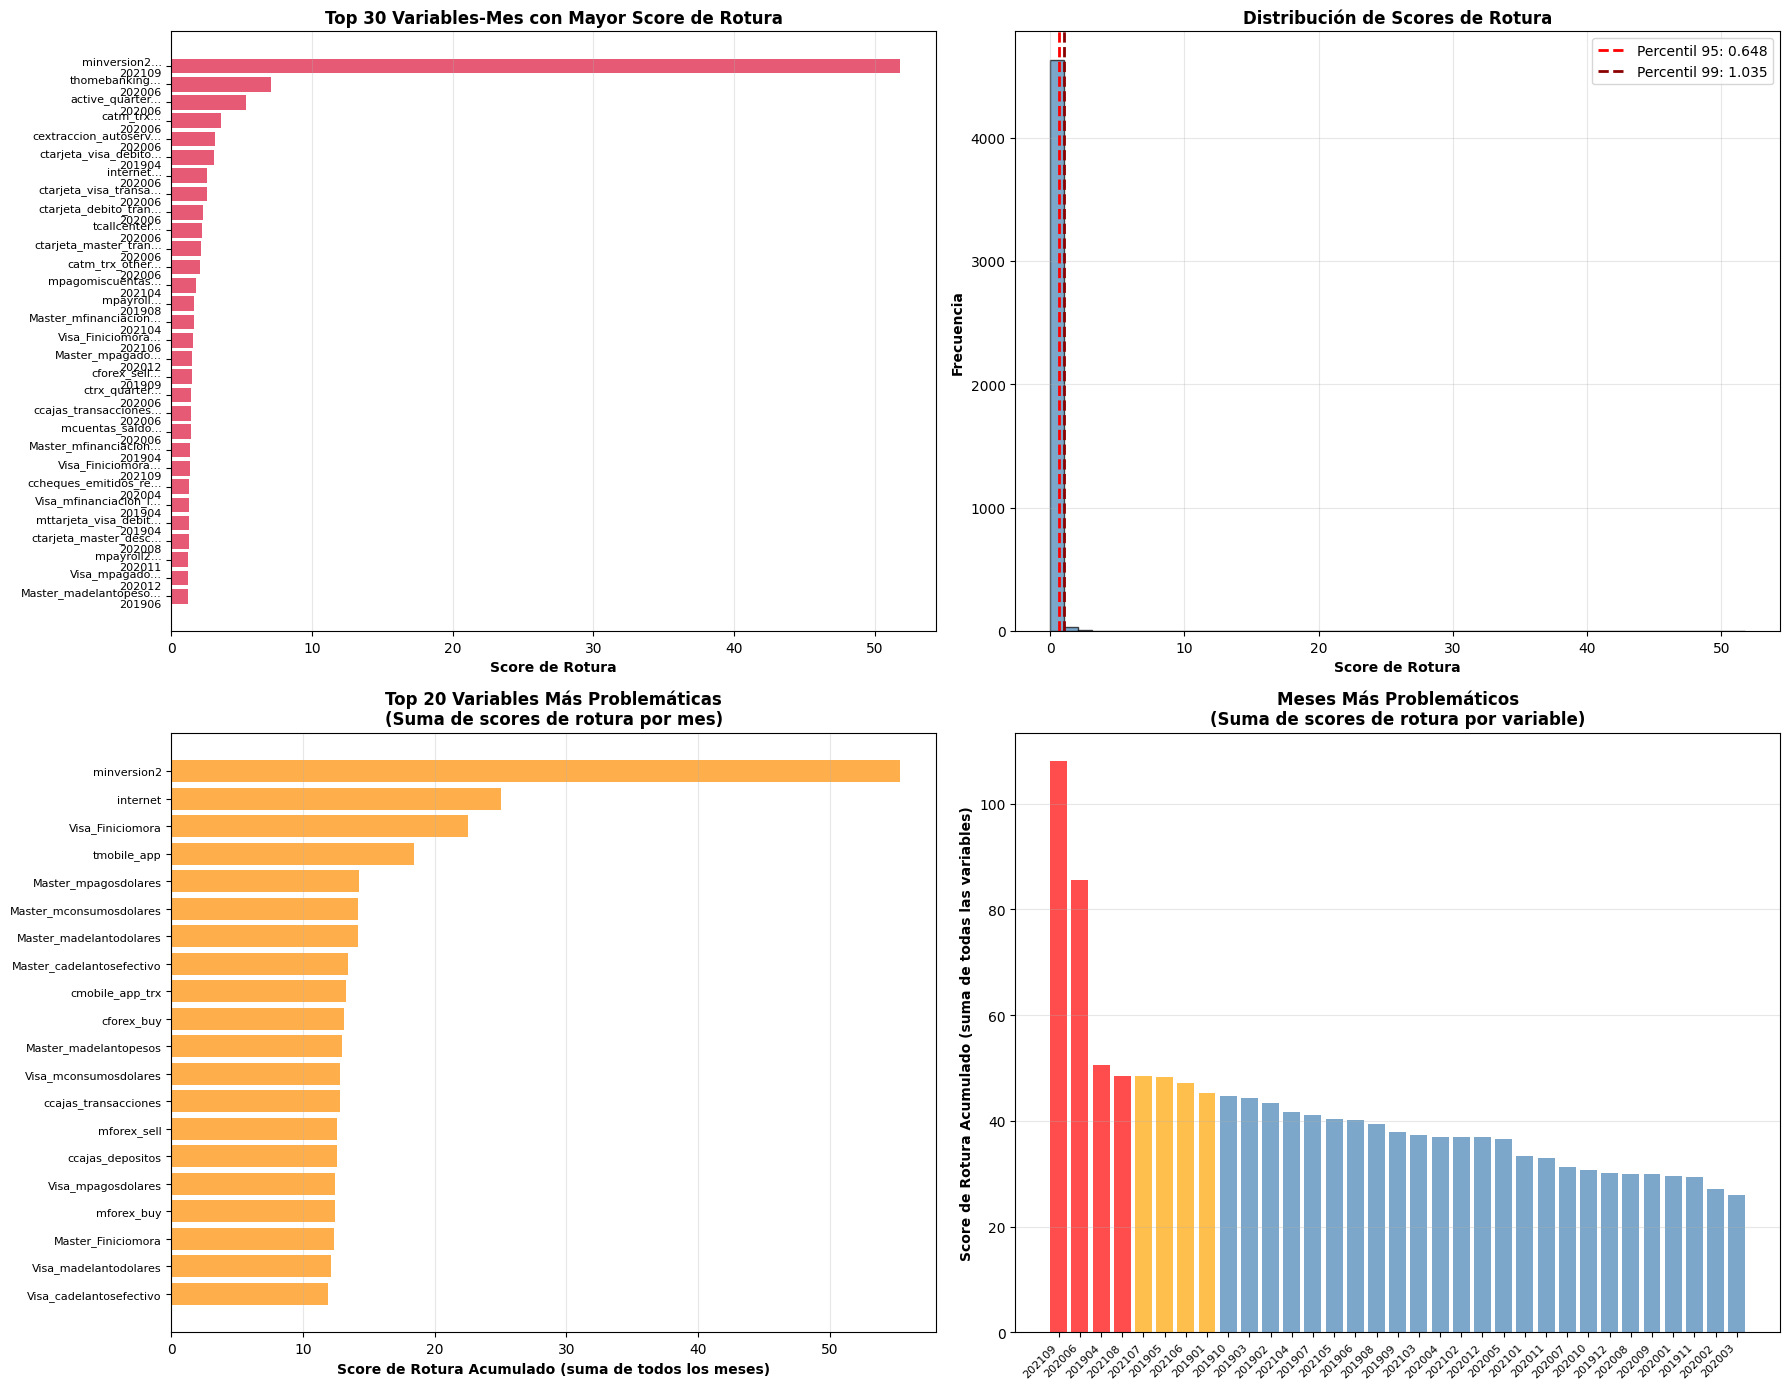

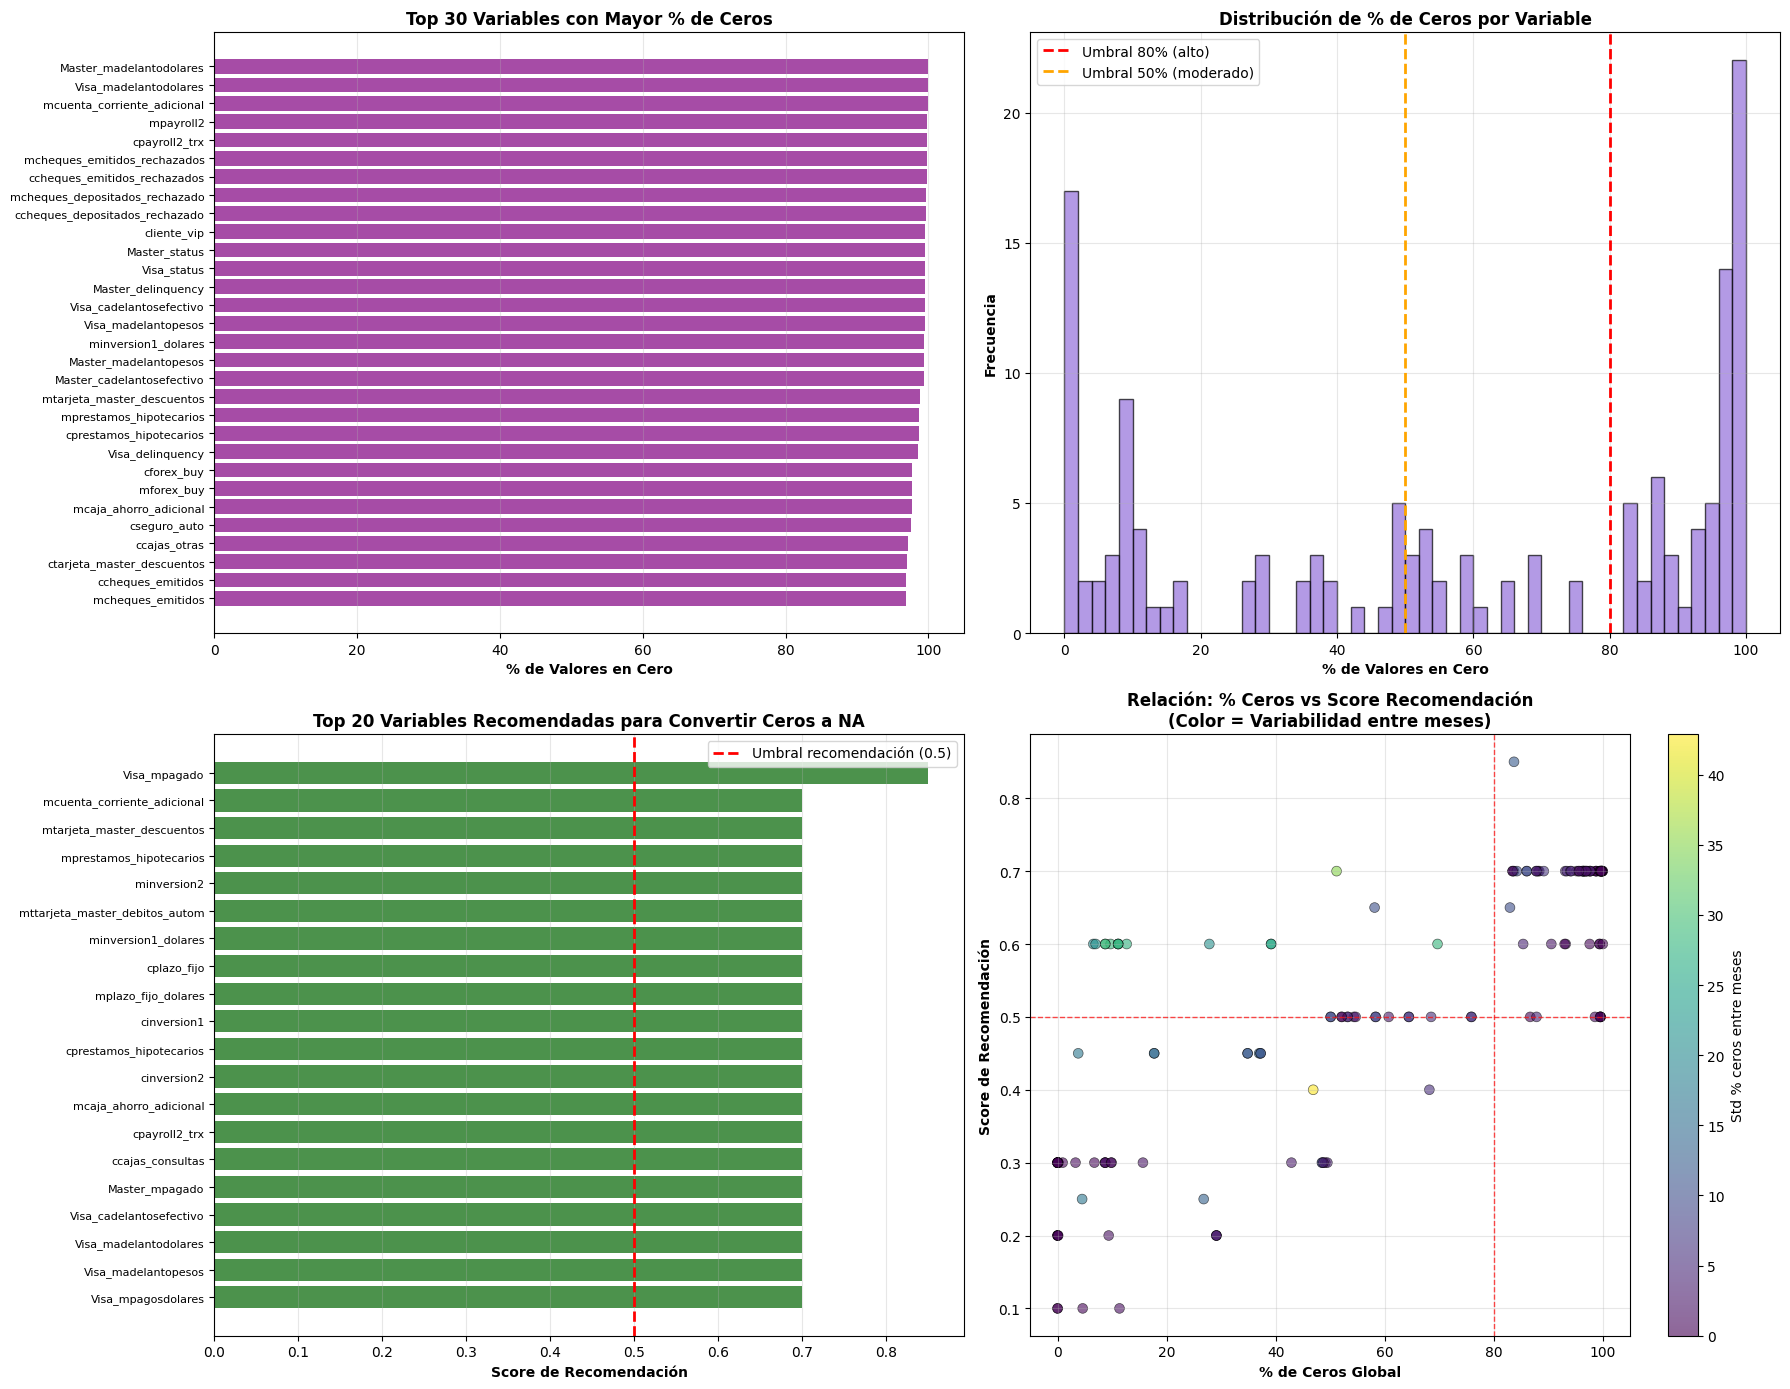


RESUMEN EJECUTIVO FINAL CONSOLIDADO

📊 RESUMEN DE VARIABLES ROTAS POR MES
--------------------------------------------------------------------------------
Total de combinaciones variable-mes analizadas: 4,674
Variables únicas analizadas: 142
Meses únicos analizados: 33

🔴 Top 10 Variables Más Problemáticas (score acumulado):
    1. minversion2                                        | Score:   55.309 | Meses rotos: 1
    2. internet                                           | Score:   25.044 | Meses rotos: 33
    3. Visa_Finiciomora                                   | Score:   22.508 | Meses rotos: 33
    4. tmobile_app                                        | Score:   18.427 | Meses rotos: 27
    5. Master_mpagosdolares                               | Score:   14.270 | Meses rotos: 29
    6. Master_mconsumosdolares                            | Score:   14.192 | Meses rotos: 26
    7. Master_madelantodolares                            | Score:   14.153 | Meses rotos: 25
    8. Master_c

In [12]:
%%time
# =========================
# VISUALIZACIONES Y RESUMEN EJECUTIVO FINAL CONSOLIDADO
# =========================

print("="*80)
print("VISUALIZACIONES Y RESUMEN EJECUTIVO FINAL")
print("="*80)

# Asegurarse de que tenemos los DataFrames del análisis anterior
# (Si se ejecutó la celda anterior, estos ya existen)
if 'df_resultados' in locals() and 'df_analisis_ceros' in locals():
    
    # 1. Visualización: Top 30 variables-mes más rotas
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    # 1.1. Top 30 variables-mes por score de rotura
    ax1 = axes[0, 0]
    top_30_rotas = df_resultados.head(30)
    # Crear etiquetas combinando variable y mes
    labels = [f"{row['variable'][:20]}...\n{row['foto_mes']}" 
              for _, row in top_30_rotas.iterrows()]
    
    ax1.barh(range(len(top_30_rotas)), top_30_rotas['score_rotura'].values, 
             color='crimson', alpha=0.7)
    ax1.set_yticks(range(len(top_30_rotas)))
    ax1.set_yticklabels(labels, fontsize=8)
    ax1.set_xlabel('Score de Rotura', fontsize=10, fontweight='bold')
    ax1.set_title('Top 30 Variables-Mes con Mayor Score de Rotura', 
                  fontsize=12, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # 1.2. Distribución de scores de rotura
    ax2 = axes[0, 1]
    ax2.hist(df_resultados['score_rotura'], bins=50, edgecolor='black', 
             alpha=0.7, color='steelblue')
    ax2.axvline(df_resultados['score_rotura'].quantile(0.95), 
                color='red', linestyle='--', linewidth=2, 
                label=f"Percentil 95: {df_resultados['score_rotura'].quantile(0.95):.3f}")
    ax2.axvline(df_resultados['score_rotura'].quantile(0.99), 
                color='darkred', linestyle='--', linewidth=2, 
                label=f"Percentil 99: {df_resultados['score_rotura'].quantile(0.99):.3f}")
    ax2.set_xlabel('Score de Rotura', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Frecuencia', fontsize=10, fontweight='bold')
    ax2.set_title('Distribución de Scores de Rotura', 
                  fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # 1.3. Variables más problemáticas (agrupadas por variable, sumando scores)
    ax3 = axes[1, 0]
    vars_mas_problematicas = (df_resultados.groupby('variable')['score_rotura']
                              .sum()
                              .sort_values(ascending=False)
                              .head(20))
    
    ax3.barh(range(len(vars_mas_problematicas)), vars_mas_problematicas.values,
             color='darkorange', alpha=0.7)
    ax3.set_yticks(range(len(vars_mas_problematicas)))
    ax3.set_yticklabels([v[:30] for v in vars_mas_problematicas.index], fontsize=8)
    ax3.set_xlabel('Score de Rotura Acumulado (suma de todos los meses)', 
                   fontsize=10, fontweight='bold')
    ax3.set_title('Top 20 Variables Más Problemáticas\n(Suma de scores de rotura por mes)', 
                  fontsize=12, fontweight='bold')
    ax3.invert_yaxis()
    ax3.grid(axis='x', alpha=0.3)
    
    # 1.4. Meses más problemáticos (agrupados por mes, sumando scores)
    ax4 = axes[1, 1]
    meses_mas_problematicos = (df_resultados.groupby('foto_mes')['score_rotura']
                                .sum()
                                .sort_values(ascending=False))
    
    colors_mes = ['red' if score > meses_mas_problematicos.quantile(0.9) 
                  else 'orange' if score > meses_mas_problematicos.quantile(0.75)
                  else 'steelblue' 
                  for score in meses_mas_problematicos.values]
    
    ax4.bar(range(len(meses_mas_problematicos)), meses_mas_problematicos.values,
            color=colors_mes, alpha=0.7)
    ax4.set_xticks(range(len(meses_mas_problematicos)))
    ax4.set_xticklabels(meses_mas_problematicos.index, rotation=45, ha='right', fontsize=8)
    ax4.set_ylabel('Score de Rotura Acumulado (suma de todas las variables)', 
                   fontsize=10, fontweight='bold')
    ax4.set_title('Meses Más Problemáticos\n(Suma de scores de rotura por variable)', 
                  fontsize=12, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Visualización: Análisis de ceros
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    # 2.1. Top 30 variables con más ceros
    ax1 = axes[0, 0]
    top_30_ceros = df_analisis_ceros.nlargest(30, 'pct_ceros_global')
    ax1.barh(range(len(top_30_ceros)), top_30_ceros['pct_ceros_global'].values,
             color='purple', alpha=0.7)
    ax1.set_yticks(range(len(top_30_ceros)))
    ax1.set_yticklabels([v[:30] for v in top_30_ceros['variable']], fontsize=8)
    ax1.set_xlabel('% de Valores en Cero', fontsize=10, fontweight='bold')
    ax1.set_title('Top 30 Variables con Mayor % de Ceros', 
                  fontsize=12, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # 2.2. Distribución de % de ceros
    ax2 = axes[0, 1]
    ax2.hist(df_analisis_ceros['pct_ceros_global'], bins=50, edgecolor='black',
             alpha=0.7, color='mediumpurple')
    ax2.axvline(80, color='red', linestyle='--', linewidth=2, 
                label='Umbral 80% (alto)')
    ax2.axvline(50, color='orange', linestyle='--', linewidth=2, 
                label='Umbral 50% (moderado)')
    ax2.set_xlabel('% de Valores en Cero', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Frecuencia', fontsize=10, fontweight='bold')
    ax2.set_title('Distribución de % de Ceros por Variable', 
                  fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # 2.3. Variables recomendadas para convertir ceros a NA
    ax3 = axes[1, 0]
    vars_recomendadas = df_analisis_ceros[df_analisis_ceros['score_recomendacion_cero_a_na'] > 0.5]
    top_20_recomendadas = vars_recomendadas.nlargest(20, 'score_recomendacion_cero_a_na')
    
    ax3.barh(range(len(top_20_recomendadas)), 
             top_20_recomendadas['score_recomendacion_cero_a_na'].values,
             color='darkgreen', alpha=0.7)
    ax3.set_yticks(range(len(top_20_recomendadas)))
    ax3.set_yticklabels([v[:30] for v in top_20_recomendadas['variable']], fontsize=8)
    ax3.set_xlabel('Score de Recomendación', fontsize=10, fontweight='bold')
    ax3.set_title('Top 20 Variables Recomendadas para Convertir Ceros a NA', 
                  fontsize=12, fontweight='bold')
    ax3.axvline(0.5, color='red', linestyle='--', linewidth=2, 
                label='Umbral recomendación (0.5)')
    ax3.invert_yaxis()
    ax3.legend()
    ax3.grid(axis='x', alpha=0.3)
    
    # 2.4. Scatter: % ceros vs score de recomendación
    ax4 = axes[1, 1]
    scatter = ax4.scatter(df_analisis_ceros['pct_ceros_global'],
                          df_analisis_ceros['score_recomendacion_cero_a_na'],
                          c=df_analisis_ceros['std_pct_ceros_entre_meses'],
                          cmap='viridis', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    ax4.set_xlabel('% de Ceros Global', fontsize=10, fontweight='bold')
    ax4.set_ylabel('Score de Recomendación', fontsize=10, fontweight='bold')
    ax4.set_title('Relación: % Ceros vs Score Recomendación\n(Color = Variabilidad entre meses)', 
                  fontsize=12, fontweight='bold')
    ax4.axvline(80, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax4.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax4.grid(alpha=0.3)
    plt.colorbar(scatter, ax=ax4, label='Std % ceros entre meses')
    
    plt.tight_layout()
    plt.show()
    
    # 3. RESUMEN EJECUTIVO FINAL CONSOLIDADO
    print("\n" + "="*80)
    print("RESUMEN EJECUTIVO FINAL CONSOLIDADO")
    print("="*80)
    
    # 3.1. Resumen de variables rotas
    print("\n📊 RESUMEN DE VARIABLES ROTAS POR MES")
    print("-" * 80)
    print(f"Total de combinaciones variable-mes analizadas: {len(df_resultados):,}")
    print(f"Variables únicas analizadas: {df_resultados['variable'].nunique()}")
    print(f"Meses únicos analizados: {df_resultados['foto_mes'].nunique()}")
    
    # Variables más problemáticas (top 10)
    vars_top = (df_resultados.groupby('variable')['score_rotura']
                .sum()
                .sort_values(ascending=False)
                .head(10))
    
    print(f"\n🔴 Top 10 Variables Más Problemáticas (score acumulado):")
    for i, (var, score) in enumerate(vars_top.items(), 1):
        n_meses_rotos = len(df_resultados[(df_resultados['variable'] == var) & 
                                          (df_resultados['score_rotura'] > 0.3)])
        print(f"   {i:2d}. {var[:50]:50s} | Score: {score:8.3f} | Meses rotos: {n_meses_rotos}")
    
    # Meses más problemáticos (top 10)
    meses_top = (df_resultados.groupby('foto_mes')['score_rotura']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))
    
    print(f"\n📅 Top 10 Meses Más Problemáticos (score acumulado):")
    for i, (mes, score) in enumerate(meses_top.items(), 1):
        n_vars_rotas = len(df_resultados[(df_resultados['foto_mes'] == mes) & 
                                         (df_resultados['score_rotura'] > 0.3)])
        print(f"   {i:2d}. Mes {mes} | Score: {score:8.3f} | Variables rotas: {n_vars_rotas}")
    
    # 3.2. Resumen de análisis de ceros
    print("\n" + "="*80)
    print("📊 RESUMEN DE ANÁLISIS DE VARIABLES CON CEROS")
    print("-" * 80)
    print(f"Total de variables analizadas: {len(df_analisis_ceros)}")
    
    vars_alto_ceros = df_analisis_ceros[df_analisis_ceros['pct_ceros_global'] > 80]
    print(f"Variables con >80% de ceros: {len(vars_alto_ceros)}")
    
    vars_recomendadas_ceros = df_analisis_ceros[df_analisis_ceros['score_recomendacion_cero_a_na'] > 0.5]
    print(f"Variables recomendadas para convertir ceros a NA: {len(vars_recomendadas_ceros)}")
    
    print(f"\n✅ Top 10 Variables Recomendadas para Convertir Ceros a NA:")
    for i, (_, row) in enumerate(vars_recomendadas_ceros.head(10).iterrows(), 1):
        print(f"   {i:2d}. {row['variable'][:50]:50s} | % ceros: {row['pct_ceros_global']:6.2f}% | Score: {row['score_recomendacion_cero_a_na']:.3f}")
    
    # 3.3. Resumen ejecutivo final (top 50 variables-mes más rotas)
    print("\n" + "="*80)
    print("📋 RESUMEN EJECUTIVO: TOP 50 VARIABLES-MES MÁS ROTAS")
    print("="*80)
    print("(Ordenadas de mayor a menor score de rotura)")
    print("-" * 80)
    
    resumen_final = df_resultados.head(50)[[
        'variable', 'foto_mes', 'score_rotura', 
        'z_score_media', 'z_score_std', 'psi',
        'pct_desviacion_media', 'pct_ceros_mes', 'pct_nulos_mes'
    ]].copy()
    
    # Formatear para mejor legibilidad
    resumen_final['z_score_media'] = resumen_final['z_score_media'].round(2)
    resumen_final['z_score_std'] = resumen_final['z_score_std'].round(2)
    resumen_final['psi'] = resumen_final['psi'].round(3)
    resumen_final['pct_desviacion_media'] = resumen_final['pct_desviacion_media'].round(1)
    resumen_final['pct_ceros_mes'] = resumen_final['pct_ceros_mes'].round(1)
    resumen_final['pct_nulos_mes'] = resumen_final['pct_nulos_mes'].round(1)
    resumen_final['score_rotura'] = resumen_final['score_rotura'].round(3)
    
    print(resumen_final.to_string(index=False))
    
    # Guardar resumen ejecutivo final
    resumen_final.to_csv("resumen_ejecutivo_final_variables_rotas.csv", index=False)
    print(f"\n✅ Resumen ejecutivo final guardado en: resumen_ejecutivo_final_variables_rotas.csv")
    
    # 3.4. Recomendaciones finales
    print("\n" + "="*80)
    print("💡 RECOMENDACIONES FINALES")
    print("="*80)
    print("\n1. VARIABLES A CORREGIR POR MES:")
    print("   - Revisar las top 50 variables-mes identificadas en el resumen ejecutivo")
    print("   - Priorizar corrección de variables con score_rotura > 0.5")
    print("   - Variables con z_score_media o z_score_std > 2 son críticas")
    
    print("\n2. CONVERSIÓN DE CEROS A NA:")
    print(f"   - {len(vars_recomendadas_ceros)} variables recomendadas para convertir ceros a NA")
    print("   - Esto puede mejorar el rendimiento de LightGBM al tratar ceros como missing")
    print("   - Implementar: df[var] = df[var].replace(0, np.nan) para variables recomendadas")
    
    print("\n3. MESES PRIORITARIOS PARA REVISIÓN:")
    for mes, score in meses_top.head(5).items():
        print(f"   - Mes {mes}: Score acumulado {score:.2f}")
    
    print("\n4. PRÓXIMOS PASOS:")
    print("   - Revisar archivos CSV generados para detalles completos")
    print("   - Implementar correcciones en el pipeline de feature engineering")
    print("   - Validar mejoras con experimentos controlados")
    print("   - Monitorear impacto en métricas de LightGBM")
    
    print("\n" + "="*80)
    
else:
    print("⚠️  ERROR: No se encontraron los DataFrames del análisis anterior.")
    print("   Por favor, ejecuta primero las celdas de análisis de variables rotas y análisis de ceros.")
    print("="*80)


In [13]:
# =========================
# Feature engineering: agregados de montos/contadores
# =========================

# Totales de saldos en pesos
SALDOS_PESOS = [
    "mcuenta_corriente",
    "mcaja_ahorro",
    "mcuenta_corriente_adicional",
    "mcaja_ahorro_adicional",
    "mcuentas_saldo",
]

# Consumo tarjetas pesos
CONSUMO_TARJETAS_PESOS = [
    "mtarjeta_visa_consumo",
    "mtarjeta_master_consumo",
]

# Consumo tarjetas dólares
CONSUMO_TARJETAS_DOLARES = [
    "Visa_mconsumosdolares",
    "Master_mconsumosdolares",
]

# Pagos recurrentes pesos
PAGOS_RECURRENTE_PESOS = [
    "mpagodeservicios",
    "mpagomiscuentas",
    "mcuenta_debitos_automaticos",
    "mttarjeta_visa_debitos_automaticos",
    "mttarjeta_master_debitos_automaticos",
]

# Sumas de productos de inversión y plazos fijos pesos
INVERSIONES_PESOS = [
    "mplazo_fijo_pesos",
    "minversion1_pesos",
    "minversion2",
]

# Sumas de productos de inversión y plazos fijos dólares
INVERSIONES_DOLARES = [
    "mplazo_fijo_dolares",
    "minversion1_dolares",
]

# Endeudamiento total pesos
ENDEUDAMIENTO_PESOS = [
    "mprestamos_prendarios",
    "mprestamos_hipotecarios",
    "Master_msaldopesos",
    "Visa_msaldopesos",
    "Master_madelantopesos",
    "Visa_madelantopesos",
]

# Endeudamiento total dólares
ENDEUDAMIENTO_DOLARES = [
    "Master_msaldodolares",
    "Visa_msaldodolares",
    "Master_madelantodolares",
    "Visa_madelantodolares",
]

# Ingresos payroll pesos
PAYROLL_PESOS = [
    "mpayroll",
    "mpayroll2",
]

# Límites de compra
LIMITES_COMPRA = [
    "Master_mlimitecompra",
    "Visa_mlimitecompra",
]

# Suma de seguros contratados
SEGUROS_COUNT = [
    "cseguro_vida",
    "cseguro_auto",
    "cseguro_vivienda",
    "cseguro_accidentes_personales",
]

# Totales de transacciones (conteo)
TRANSACCIONES_COUNT = [
    "ctarjeta_debito_transacciones",
    "ctarjeta_visa_transacciones",
    "ctarjeta_master_transacciones",
    "chomebanking_transacciones",
    "cmobile_app_trx",
    "ccallcenter_transacciones",
    "catm_trx",
    "catm_trx_other",
    "ccajas_transacciones",
]

def sum_columns_safe(df: pl.DataFrame, cols: list[str]) -> pl.Series:
    existentes = [c for c in cols if c in df.columns]
    if not existentes:
        return pl.lit(0)
    return pl.sum_horizontal([pl.col(c) for c in existentes])

fe_columns = {
    "m_saldo_total_pesos": SALDOS_PESOS,
    "m_consumo_tarjetas_pesos": CONSUMO_TARJETAS_PESOS,
    "m_consumo_tarjetas_dolares": CONSUMO_TARJETAS_DOLARES,
    "m_pagos_recurrentes_pesos": PAGOS_RECURRENTE_PESOS,
    "m_inversiones_pesos": INVERSIONES_PESOS,
    "m_inversiones_dolares": INVERSIONES_DOLARES,
    "m_endeudamiento_pesos": ENDEUDAMIENTO_PESOS,
    "m_endeudamiento_dolares": ENDEUDAMIENTO_DOLARES,
    "m_payroll_total": PAYROLL_PESOS,
    "m_limite_compra_total": LIMITES_COMPRA,
    "c_seguros_total": SEGUROS_COUNT,
    "c_transacciones_total": TRANSACCIONES_COUNT,
}

df = df.with_columns([
    sum_columns_safe(df, cols).alias(col_name)
    for col_name, cols in fe_columns.items()
])

df.shape

(4883051, 167)

In [14]:
%%time
# =========================
# 4) Feature Engineering Histórico - Lags y DeltaLags
# =========================

# Excluir IDs y metadata
EXCLUDE = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Identificar columnas numéricas
num_cols = [c for c, dt in zip(df.columns, df.dtypes)
            if c not in EXCLUDE and dt.is_numeric()]

def add_lags_and_deltas(df: pl.DataFrame, cols: list[str]) -> pl.DataFrame:
    """
    Agregar lags y deltas de orden 1 y 2 - Baseline del profesor
    """
    out = df.sort(["numero_de_cliente", "foto_mes"]).lazy()

    # Lags 1 y 2
    out = out.with_columns([
        pl.col(c).shift(1).over("numero_de_cliente").alias(f"{c}_lag1") for c in cols
    ] + [
        pl.col(c).shift(2).over("numero_de_cliente").alias(f"{c}_lag2") for c in cols
    ])

    # Delta 1: x_t - x_{t-1} ; Delta 2: x_t - x_{t-2}
    out = out.with_columns([
        (pl.col(c) - pl.col(f"{c}_lag1")).alias(f"{c}_d1") for c in cols
    ] + [
        (pl.col(c) - pl.col(f"{c}_lag2")).alias(f"{c}_d2") for c in cols
    ])

    return out.collect()

# Aplicar lags y deltas
df = add_lags_and_deltas(df, num_cols)

df.shape

CPU times: user 2min 13s, sys: 41 s, total: 2min 54s
Wall time: 2min 29s


(4883051, 823)

In [15]:
# =========================
# 4.1) Creacion de Canaritos
# =========================

plocal = SimpleNamespace(
    qcanaritos=5,
    min_data_in_leaf=20,
    learning_rate=1.0,
    gradient_bound=0.1,
    APO=10,
    ksemillerio=1,
)

df = create_canaritos(df, plocal.qcanaritos)

In [16]:
# Configuración de la competencia
TRAIN_MESES = [
    201901, 201902, 201903, #201904, 
    201905, 201906, 201907, 201908, 
    201909, 201910, 201911, 201912, 
    202001, 202002, 202003, 202004, 202005, #202006, 
    202007, 202008, 202009, #202010, 
    202011, 202012, 202101, 202102,
    202103, 202104, 202105
]

TEST_MES   = 202107
TEST_MES2   = 202107

APPLY_MES = 202107


In [17]:
%%time
# =========================
# 5) Undersampling de todos los registros CONTINUA al 3%
# =========================

train_subset = df.filter(pl.col("foto_mes").is_in(TRAIN_MESES))

# Separar registros por clase
registros_continua = train_subset.filter(pl.col("clase_ternaria") == "CONTINUA")
registros_baja = train_subset.filter(pl.col("clase_ternaria").is_in(["BAJA+1", "BAJA+2"]))

# Hacer undersampling del 3% de todos los registros CONTINUA
fraccion_sample = 0.03
n_total_continua = registros_continua.height
n_sample = max(1, int(np.ceil(n_total_continua * fraccion_sample)))

registros_continua_sample = registros_continua.sample(n=n_sample, seed=SEEDS[0])

# Combinar registros CONTINUA muestreados con todos los BAJA
_df_train = pl.concat([registros_continua_sample, registros_baja])
_df_test = df.filter(pl.col("foto_mes") == TEST_MES)
_df_apply = df.filter(pl.col("foto_mes") == APPLY_MES)

CPU times: user 45.5 s, sys: 55.3 s, total: 1min 40s
Wall time: 13.1 s


In [18]:
# =========================
# 5.1) Validación de la data
# =========================

print("_df_train shape:", _df_train.shape)
print("_df_test shape:", _df_test.shape)
print("_df_apply shape:", _df_apply.shape)
print("Primeras columnas en df      :", df.columns[:10])
print("Primeras columnas en _df_train:", _df_train.columns[:10])

_df_train shape: (145744, 828)
_df_test shape: (164596, 828)
_df_apply shape: (164596, 828)
Primeras columnas en df      : ['canarito_1', 'canarito_2', 'canarito_3', 'canarito_4', 'canarito_5', 'numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet']
Primeras columnas en _df_train: ['canarito_1', 'canarito_2', 'canarito_3', 'canarito_4', 'canarito_5', 'numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet']


In [19]:
%%time
# =========================
# 6) Entrenamiento LightGBM con métrica de ganancia (semillero)
# =========================

plocal = SimpleNamespace(
    qcanaritos=5,
    min_data_in_leaf=20,
    learning_rate=1.0,
    gradient_bound=0.1,
    APO=10,
    ksemillerio=1,   
)

PARAM = SimpleNamespace(
    semilla_primigenia=SEEDS[0],  
    qcanaritos=plocal.qcanaritos,
)

# Constantes de ganancia
GANANCIA_ACIERTO = 780000
COSTO_ESTIMULO = 20000

def calcular_ganancias_acumuladas(y_true, y_pred_proba):
    """Calcula la ganancia acumulada ordenando por probabilidad descendente."""
    df_eval = pl.DataFrame({"y_true": y_true, "y_pred_proba": y_pred_proba})
    df_ordenado = df_eval.sort("y_pred_proba", descending=True)
    df_ordenado = df_ordenado.with_columns(
        pl.when(pl.col("y_true") == 1)
        .then(GANANCIA_ACIERTO)
        .otherwise(-COSTO_ESTIMULO)
        .alias("ganancia_individual")
    )
    df_ordenado = df_ordenado.with_columns(
        pl.col("ganancia_individual").cast(pl.Int64).cum_sum().alias("ganancia_acumulada")
    )
    return df_ordenado["ganancia_acumulada"].to_numpy()

# Convertir a pandas
train_pd = _df_train.to_pandas()
test_pd = _df_test.to_pandas()
apply_pd = _df_apply.to_pandas()  # si lo necesitas después

drop_cols = {"numero_de_cliente", "foto_mes", "clase_ternaria"}
feature_cols = [c for c in train_pd.columns if c not in drop_cols]

print("=== Dataset shapes ===")
print(f"train: {train_pd.shape} | test: {test_pd.shape}")
print(f"Features disponibles: {len(feature_cols)} (incluye canaritos={plocal.qcanaritos})")

# Targets y pesos
y_train = train_pd["clase_ternaria"].isin(["BAJA+1", "BAJA+2"]).astype(int)

weight_train = np.where(y_train == 1, 1.00002, 1.0)

lgb_train = lgb.Dataset(train_pd[feature_cols], label=y_train, weight=weight_train)

num_boost_round = 9999

print("\n=== Configuración del semillero ===")
print(f"semilla_primigenia={PARAM.semilla_primigenia}")
print(f"qcanaritos={PARAM.qcanaritos}")
print(f"ksemillerio={plocal.ksemillerio}")
print(f"num_boost_round={num_boost_round}")

# Para guardar resultados de cada seed
resultados_semillas = []

print("\n=== Comenzando entrenamiento del semillero ===")

for i, seed in enumerate(SEEDS[:plocal.ksemillerio], start=1):
    print(f"\n[Seed {i}/{plocal.ksemillerio}] Entrenando modelo con seed={seed} ...")

    lgbm_param_completo = {
        "boosting": "gbdt",
        "objective": "binary",
        "metric": "None",
        "first_metric_only": False,
        "boost_from_average": True,
        "feature_pre_filter": False,
        "force_row_wise": True,
        "verbosity": -100,
        "seed": int(seed),
        "max_bin": 31,
        "min_data_in_leaf": plocal.min_data_in_leaf,
        "num_leaves": 9999,
        "learning_rate": plocal.learning_rate,
        "feature_fraction": 0.50,
        "canaritos": PARAM.qcanaritos,
        "gradient_bound": plocal.gradient_bound,
    }

    print(
        f"  -> Parámetros: seed={lgbm_param_completo['seed']}, "
        f"min_leaf={plocal.min_data_in_leaf}, lr={plocal.learning_rate}, "
        f"num_leaves={lgbm_param_completo['num_leaves']}, "
        f"feature_fraction={lgbm_param_completo['feature_fraction']}"
    )

    model = lgb.train(
        lgbm_param_completo,
        train_set=lgb_train,
        num_boost_round=num_boost_round,
    )

    best_iteration = model.best_iteration or num_boost_round

    apply_pd["pred_lgbm"] = model.predict(apply_pd[feature_cols], num_iteration=best_iteration)

    # Predicción en test
    valid_scores = model.predict(test_pd[feature_cols], num_iteration=best_iteration)

=== Dataset shapes ===
train: (145744, 828) | test: (164596, 828)
Features disponibles: 825 (incluye canaritos=5)

=== Configuración del semillero ===
semilla_primigenia=509963
qcanaritos=5
ksemillerio=1
num_boost_round=9999

=== Comenzando entrenamiento del semillero ===

[Seed 1/1] Entrenando modelo con seed=509963 ...
  -> Parámetros: seed=509963, min_leaf=20, lr=1.0, num_leaves=9999, feature_fraction=0.5
CPU times: user 2h 37min 32s, sys: 26.1 s, total: 2h 37min 58s
Wall time: 20min 8s


In [20]:
%%time
# =========================
# 7) Ganancia real en TEST 202107
# =========================

test_pred_df = (
    pl.DataFrame(
        {
            "numero_de_cliente": test_pd["numero_de_cliente"],
            "foto_mes": test_pd["foto_mes"],
            "clase_ternaria": test_pd["clase_ternaria"],
            "probabilidad_baja": valid_scores,
        }
    )
    .with_columns(
        pl.col("clase_ternaria").eq("BAJA+2").cast(pl.Int64).alias("es_baja2")
    )
    .sort("probabilidad_baja", descending=True)
    .with_row_count("rank_envio", offset=1)
)

ganancias_acumuladas = calcular_ganancias_acumuladas(
    test_pred_df["es_baja2"].to_numpy(),
    test_pred_df["probabilidad_baja"].to_numpy(),
)

test_pred_df = test_pred_df.with_columns(
    pl.Series("ganancia_acumulada", ganancias_acumuladas)
)

ganancia_maxima = float(ganancias_acumuladas.max())
idx_mejor = int(np.argmax(ganancias_acumuladas))
n_envios_optimo = idx_mejor + 1

ganancia_envio_11000 = (
    int(ganancias_acumuladas[10999])
    if len(ganancias_acumuladas) >= 11000
    else None
)

print("=== Ganancia TEST 202107 ===")
print(f"Ganancia máxima: {ganancia_maxima:,.0f}")
print(f"Envíos óptimos: {n_envios_optimo} clientes")
if ganancia_envio_11000 is not None:
    print(f"Ganancia en 11.000 envíos: {ganancia_envio_11000:,.0f}")
else:
    print("Ganancia en 11.000 envíos: N/A (menos registros)")


=== Ganancia TEST 202107 ===
Ganancia máxima: 430,360,000
Envíos óptimos: 13842 clientes
Ganancia en 11.000 envíos: 428,000,000
CPU times: user 60.5 ms, sys: 9.77 ms, total: 70.3 ms
Wall time: 37.1 ms


<timed exec>:18: DeprecationWarning: `DataFrame.with_row_count` is deprecated. Use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.


Top 10 features por gain
                         feature           gain  split
110                 ctrx_quarter  312705.744884  28891
21                  mcaja_ahorro  176414.835542  21444
158     m_consumo_tarjetas_pesos   81262.898753  10917
54                  cpayroll_trx   75307.436995   2760
30   ctarjeta_visa_transacciones   66879.106757  10588
157          m_saldo_total_pesos   61452.090723  17939
31         mtarjeta_visa_consumo   55025.238571   8756
274            ctrx_quarter_lag1   42801.879529  18240
136                  Visa_status   29346.486588    745
168        c_transacciones_total   28125.788476  23073


/tmp/ipykernel_6938/304525469.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


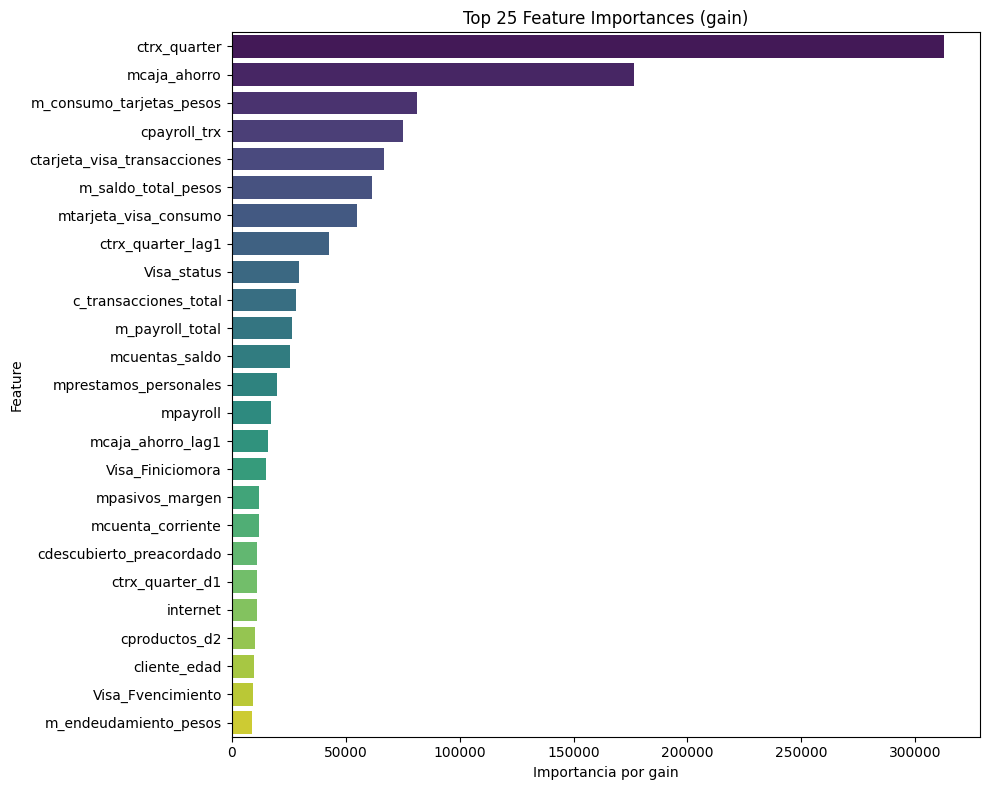

In [21]:
# =========================
# 8) Feature importance del modelo LightGBM
# =========================

feature_importance_gain = model.feature_importance(importance_type="gain")
feature_importance_split = model.feature_importance(importance_type="split")

importance_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "gain": feature_importance_gain,
            "split": feature_importance_split,
        }
    )
    .sort_values("gain", ascending=False)
)

print("Top 10 features por gain")
print(importance_df.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(25),
    x="gain",
    y="feature",
    palette="viridis",
)
plt.title("Top 25 Feature Importances (gain)")
plt.xlabel("Importancia por gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [22]:
%%time
# =========================
# 9) Predicciones binarias finales y archivo submit
# =========================

models = [model]
predictions_per_seed = [apply_pd["pred_lgbm"].to_numpy()]

predictions_matrix = np.vstack(predictions_per_seed)
final_predictions = np.mean(predictions_matrix, axis=0)

clientes_ordenados = np.argsort(final_predictions)[::-1]

n_clientes_objetivo = 11000
predicciones_binarias = np.zeros(len(final_predictions), dtype=int)
predicciones_binarias[clientes_ordenados[:n_clientes_objetivo]] = 1

id_apply = apply_pd["numero_de_cliente"].to_numpy()
submit_df = pd.DataFrame(
    {
        "numero_de_cliente": id_apply[clientes_ordenados],
        "Predicted": predicciones_binarias[clientes_ordenados],
    }
)

submit_df

submit_path = BASE_DIR / "verificar_202106_submit_lgbm.csv"
submit_path.parent.mkdir(parents=True, exist_ok=True)
submit_df.to_csv(submit_path, index=False)

print("=== Submit APPLY listo ===")
print(f"Archivo: {submit_path}")
print(f"Clientes positivos: {predicciones_binarias.sum()} de {len(predicciones_binarias)}")

#clientes_valid_ordenados = np.argsort(valid_scores)[::-1]
#predicciones_binarias_valid = np.zeros(len(valid_scores), dtype=int)
#predicciones_binarias_valid[clientes_valid_ordenados[:n_clientes_objetivo]] = 1

#id_valid = test_pd["numero_de_cliente"].to_numpy()
#submit_valid_df = pl.DataFrame(
#    {
#        "numero_de_cliente": id_valid[clientes_valid_ordenados],
#        "Predicted": predicciones_binarias_valid[clientes_valid_ordenados],
#    }
#)

#submit_valid_path = BASE_DIR / "submit_lgbm_test202106.csv"
#submit_valid_df.write_csv(submit_valid_path)

#print("\n=== Submit TEST 202106 listo ===")
#print(f"Archivo: {submit_valid_path}")
#print(f"Clientes positivos: {predicciones_binarias_valid.sum()} de {len(predicciones_binarias_valid)}")

=== Submit APPLY listo ===
Archivo: /home/nicocaviglia031/dmeyf2025/Competencia 3/dmeyf2025/verificar_202106_submit_lgbm.csv
Clientes positivos: 11000 de 164596
CPU times: user 154 ms, sys: 2.9 ms, total: 157 ms
Wall time: 156 ms


In [23]:
# Filtrar los clientes con Predicted == 1
df_filtered_ensemble = submit_df[submit_df["Predicted"] == 1][["numero_de_cliente"]]
# Guardar CSV sin encabezados ni índice
df_filtered_ensemble.to_csv("Charizard777.csv", index=False, header=False)